<a href="https://colab.research.google.com/github/santafefa/Bin-packing-with-lower-bound-and-upper-bound/blob/main/Bin_packing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import time

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/Evolutionary_algorithm/dataset

Mounted at /content/drive
/content/drive/MyDrive/Evolutionary_algorithm/dataset


In [ ]:
pip install numba numpy

In [ ]:
from numba import jit
@jit(nopython=True)
def fast_calculate_fitness(individual, quantity, cost, lower_bound, upper_bound, vehicles_num):
    # Khởi tạo mảng load với kiểu số nguyên
    veh_load = np.zeros(vehicles_num, dtype=np.int32)
    total_cost = 0
    penalty = 0

    # Vòng lặp tính tải trọng và chi phí cơ bản
    # Numba sẽ tự động tối ưu vòng lặp này (Loop Unrolling, Vectorization)
    n = len(individual)
    for i in range(n):
        vehicle_idx = individual[i]
        if vehicle_idx != -1:
            veh_load[vehicle_idx] += quantity[i]
            total_cost += cost[i]

    # Vòng lặp tính Penalty
    for v_idx in range(vehicles_num):
        load = veh_load[v_idx]

        # Nếu xe không chở gì thì bỏ qua
        if load == 0:
            continue

        # Kiểm tra tải trọng (Logic check_validation được gộp vào đây)
        if load < lower_bound[v_idx]:
            penalty += (lower_bound[v_idx] - load) * 1000
        elif load > upper_bound[v_idx]:
            penalty += (load - upper_bound[v_idx]) * 1000

    return total_cost - penalty
class GENENTIC_ALG:
    def __init__(self, input_file=None):
        self.input_file = input_file
    '''def read_input(self):
        N, K = map(int, input().split())
        quantity = []
        cost = []
        for _ in range(N):
            q, c = map(int, input().split())
            quantity.append(q)
            cost.append(c)
        lower_bound = []
        upper_bound = []
        for _ in range(K):
            l, u = map(int, input().split())
            lower_bound.append(l)
            upper_bound.append(u)
        self.orders_num = N
        self.vehicles_num = K
        self.quantity = quantity
        self.cost = cost
        self.lower_bound = lower_bound
        self.upper_bound = upper_bound'''
    def read_input(self, file = None):
        if file is None:
            file = self.input_file
        with open(file, 'r') as f:
            N, K = map(int, f.readline().split())
            quantity = []
            cost = []
            for _ in range(N):
                q, c = map(int, f.readline().split())
                quantity.append(q)
                cost.append(c)
            lower_bound = []
            upper_bound = []
            for _ in range(K):
                l, u = map(int, f.readline().split())
                lower_bound.append(l)
                upper_bound.append(u)
        self.orders_num = N
        self.vehicles_num = K
        self.quantity = quantity
        self.cost = cost
        self.lower_bound = lower_bound
        self.upper_bound = upper_bound

        self.np_quantity = np.array(quantity, dtype=np.int32)
        self.np_cost = np.array(cost, dtype=np.int32)
        self.np_lower = np.array(lower_bound, dtype=np.int32)
        self.np_upper = np.array(upper_bound, dtype=np.int32)

    def check_validation(self, load, v_idx):
        if load == 0:
            return True
        return self.lower_bound[v_idx] <= load <= self.upper_bound[v_idx]

    '''def calculate_fitness(self, individual):
        cost=0
        veh_load = [0] * self.vehicles_num
        penalty = 0
        for order_idx, vehicle_idx in enumerate(individual):
            if vehicle_idx != -1:
                veh_load[vehicle_idx] += self.quantity[order_idx]
                cost += self.cost[order_idx]
        for vehicle_idx, load in enumerate(veh_load):
            if self.check_validation(load,vehicle_idx):
                continue
            else:
                if load > self.upper_bound[vehicle_idx]:
                    penalty += (load-self.upper_bound[vehicle_idx])*100
                elif load >0 and load < self.lower_bound[vehicle_idx]:
                    penalty += (self.lower_bound[vehicle_idx]-load)*100

        return cost - penalty'''
    def calculate_fitness(self, individual):
        # Chuyển cá thể hiện tại sang numpy array (chi phí chuyển đổi rất nhỏ)
        ind_np = np.array(individual, dtype=np.int32)

        # Gọi hàm đã được biên dịch bởi Numba
        return fast_calculate_fitness(
            ind_np,
            self.np_quantity,
            self.np_cost,
            self.np_lower,
            self.np_upper,
            self.vehicles_num
        )

    '''def repair_solution(self, individual):
        load = [0] * self.vehicles_num
        assignments = individual[:]
        curr_cost = 0
        for order_idx, vehicle_idx in enumerate(individual):
            if vehicle_idx != -1:
              load[vehicle_idx] += self.quantity[order_idx]
              curr_cost += self.cost[order_idx]
        for v_idx in range(self.vehicles_num):
            if not self.check_validation(load[v_idx], v_idx):
                for order_idx, veh_idx in enumerate(individual):
                    if veh_idx == v_idx:
                        assignments[order_idx] = -1
                        curr_cost -= self.cost[order_idx]
        return assignments, curr_cost'''
    def repair_solution(self, individual):
        load = [0] * self.vehicles_num
        assignments = individual[:]
        curr_cost = 0
        lower_bound_violated = []
        upper_bound_violated = []
        unassign_orders = []
        #Adaptive repair
        for order_idx, vehicle_idx in enumerate(individual):
            if vehicle_idx != -1:
                load[vehicle_idx] += self.quantity[order_idx]
                curr_cost += self.cost[order_idx]
            else:
                unassign_orders.append(order_idx)
        for v_id in range(self.vehicles_num):
            if load[v_id]< self.lower_bound[v_id]:
                lower_bound_violated.append(v_id)
            elif load[v_id] > self.upper_bound[v_id]:
                upper_bound_violated.append(v_id)
        for v_id in upper_bound_violated:
            while load[v_id] > self.upper_bound[v_id]:
                for order_idx, veh_idx in enumerate(individual):
                    if veh_idx == v_id and random.random()<0.5:
                        assignments[order_idx] = -1
                        curr_cost -= self.cost[order_idx]
                        load[v_id] -= self.quantity[order_idx]
                        unassign_orders.append(order_idx)
        for v_id in lower_bound_violated:
            #try_time = 0
            #while load[v_id] < self.lower_bound[v_id] and try_time < 10:
                #try_time += 1
            for order_idx, veh_idx in enumerate(individual):
                if veh_idx == v_id:
                    assignments[order_idx] = -1
                    curr_cost -= self.cost[order_idx]
                    load[v_id] -= self.quantity[order_idx]

        return assignments, curr_cost
    def greedy(self, sorted_orders: str ="cost", sorted_vehicles: str = "lower_bound"):
        load = [0] * self.vehicles_num
        assignments = [-1] * self.orders_num
        orders_rate = []
        vehicle_rate = []
        curr_cost = 0
        if sorted_orders == "cost":
            for idx, cost in enumerate(self.cost):
                orders_rate.append((idx, cost))
        elif sorted_orders == "weight":
            for idx, weight in enumerate(self.quantity):
                orders_rate.append((idx, weight))
        elif sorted_orders == "ratio":
            for idx, (weight, cost) in enumerate(zip(self.quantity, self.cost)):
                orders_rate.append((idx, cost / weight))
        orders_rate.sort(key=lambda x: x[1], reverse=True)
        if sorted_vehicles == "lower_bound":
            for idx, lower in enumerate(self.lower_bound):
                vehicle_rate.append((idx, -lower))
        elif sorted_vehicles == "upper_bound":
            for idx, upper in enumerate(self.upper_bound):
                vehicle_rate.append((idx, -upper))
        elif sorted_vehicles == "range":
            for idx, (lower, upper) in enumerate(zip(self.lower_bound, self.upper_bound)):
                vehicle_rate.append((idx, upper - lower))
        vehicle_rate.sort(key=lambda x: x[1])

        for ord_idx, _ in orders_rate:
            for veh_idx, _ in vehicle_rate:
                if load[veh_idx] + self.quantity[ord_idx] <= self.upper_bound[veh_idx]:
                    assignments[ord_idx] = veh_idx
                    load[veh_idx] += self.quantity[ord_idx]
                    curr_cost += self.cost[ord_idx]
                    break
        for v_idx in range(self.vehicles_num):
            if load[v_idx] > 0 and load[v_idx] < self.lower_bound[v_idx]:
                for ord_idx, veh_idx in enumerate(assignments):
                    if veh_idx == v_idx:
                        assignments[ord_idx] = -1
                        curr_cost -= self.cost[ord_idx]
                load[v_idx] = 0
        return assignments, curr_cost, load

    '''def create_initial_population(self, population_size):
        #initalizie population by using greedy
        population = []
        sorted_orders = ["cost", "weight", "ratio"]
        sorted_vehicles = ["lower_bound", "upper_bound", "range"]
        greedy_size = 0
        load = []
        for _ in range(greedy_size):
            individual, _, load = self.greedy(random.choice(sorted_orders), random.choice(sorted_vehicles))
            population.append(individual)

        for _ in range(population_size - greedy_size):
            individual = []
            for order_idx in range(self.orders_num):
                vehicle_idx = random.randint(-1, self.vehicles_num - 1)
                individual.append(vehicle_idx)
            population.append(individual)
        return population'''
    def get_max_possible_score(self):
        return sum(self.cost)
    def create_initial_population(self, population_size):
        population = []
        vehicle_sorted_order =['lower_bound', 'upper_bound', 'range']
        order_sorted_order = ['cost', 'weight', 'ratio']
        for _ in range(population_size):
            ord_sort = random.choice(order_sorted_order)
            veh_sort = random.choice(vehicle_sorted_order)
            individual, _, _ = self.greedy(ord_sort, veh_sort)
            population.append(individual)
        for ind in population:
            change_alens = [random.randint(-1, self.orders_num-1) for _ in range(random.randint(0,self.orders_num))]
            for i in change_alens:
                if random.random() < 0.5:
                    v_id = random.randint(-1, self.vehicles_num -1)
                    ind[i] = v_id
        return population

    def selection(self, population, fitnesses,tourment_size=3):
        chosen = random.sample(list(zip(population, fitnesses)), tourment_size)
        chosen.sort(key=lambda x: x[1], reverse=True)
        return chosen[0][0]

    def crossover(self, parent1, parent2):
        offspring1 = parent2[:]
        #offspring2 = parent1[:]
        load_off1= [0]*self.vehicles_num
        load_off2= [0]*self.vehicles_num

        for i in range(self.orders_num):
            if parent1[i] !=-1 :
              load_off2[parent1[i]] += self.quantity[i]
            if parent2[i] != -1:
              load_off1[parent2[i]] += self.quantity[i]

        for i in range(self.orders_num):
          if parent1[i] != parent2[i]:
            if offspring1[i] != -1:
              if load_off1[parent1[i]] + self.quantity[i] <= self.upper_bound[parent1[i]] :
                if load_off1[parent2[i]] > self.upper_bound[parent2[i]]:
                  offspring1[i] = parent1[i]
                  load_off1[parent1[i]] += self.quantity[i]
                  load_off1[parent2[i]] -= self.quantity[i]
              else:
                if load_off1[parent2[i]] <= self.upper_bound[parent2[i]]:
                  offspring1[i] = parent2[i]
                else:
                  if random.random() < 0.5:
                    offspring1[i] = parent1[i]
                    load_off1[parent1[i]] += self.quantity[i]
                    load_off1[parent2[i]] -= self.quantity[i]
            else:
              if load_off1[parent1[i]] + self.quantity[i] <= self.upper_bound[parent1[i]]:
                offspring1[i] = parent1[i]
                load_off1[parent1[i]] += self.quantity[i]

        return offspring1#, offspring2
    '''
    def crossover(self, parent1, parent2):
        offspring1 = parent2[:]
        # This function only creates one offspring

        load_off1 = [0] * self.vehicles_num

        # 1. Calculate the initial load of offspring1 (which is a clone of parent2)
        for i in range(self.orders_num):
            if parent2[i] != -1:
                load_off1[parent2[i]] += self.quantity[i]

        # 2. Iterate and try to swap genes from parent1
        for i in range(self.orders_num):
            # Only consider genes where parents differ
            if parent1[i] == parent2[i]:
                continue

            current_vehicle = offspring1[i] # This is parent2[i]
            target_vehicle = parent1[i] # This is the gene from parent1

            # --- Logic for if the order is currently assigned ---
            if current_vehicle != -1:
                # Check if the *target* vehicle (from parent1) can take the load
                can_take_load = False
                if target_vehicle == -1:
                    can_take_load = True # -1 (unassigned) can always take the load
                elif load_off1[target_vehicle] + self.quantity[i] <= self.upper_bound[target_vehicle]:
                    can_take_load = True

                if can_take_load:
                    # Logic: "Is the current vehicle overloaded?"
                    is_overloaded = (load_off1[current_vehicle] > self.upper_bound[current_vehicle])

                    if is_overloaded:
                        # Yes, it's overloaded. We *must* move the order.
                        offspring1[i] = target_vehicle
                        # --- BUG FIX ---
                        load_off1[current_vehicle] -= self.quantity[i]
                        if target_vehicle != -1:
                            load_off1[target_vehicle] += self.quantity[i]
                        # --- END FIX ---
                    else:
                        # "Is the current load NOT valid (i.e., overloaded)?"
                        # This is the original logic from your 'else' block
                        is_not_valid = (load_off1[current_vehicle] > self.upper_bound[current_vehicle])

                        if is_not_valid: # This is redundant, but matches your logic
                           if random.random() < 0.5:
                                offspring1[i] = target_vehicle
                                # --- BUG FIX ---
                                load_off1[current_vehicle] -= self.quantity[i]
                                if target_vehicle != -1:
                                    load_off1[target_vehicle] += self.quantity[i]
                                # --- END FIX ---
                        # If the load is valid (load_off1[current_vehicle] <= self.upper_bound[current_vehicle]),
                        # your original code did nothing, so we also do nothing.

            # --- Logic for if the order is currently unassigned (-1) ---
            else: # current_vehicle == -1
                if target_vehicle != -1: # Don't move from -1 to -1
                    # "if target (parent1's vehicle) can take the load"
                    if load_off1[target_vehicle] + self.quantity[i] <= self.upper_bound[target_vehicle]:
                        offspring1[i] = target_vehicle
                        # --- BUG FIX ---
                        load_off1[target_vehicle] += self.quantity[i]
                        # (no need to subtract from -1)
                        # --- END FIX ---

        return offspring1
'''
    def mutation(self, individual, mutation_rate=0.01):
        for i in range(self.orders_num):
            if random.random() < mutation_rate:
                diff = 0
                while not diff:
                  new_vid = random.randint(-1, self.vehicles_num - 1)
                  if new_vid != individual[i]:
                    diff = 1
                    individual[i] = new_vid
        return individual

    def solve(self, population_size=100, generations=2000, cross_over_rate = 0.9, mutation_rate=0.01, elitism_count=5):
        self.read_input()
        population= self.create_initial_population(population_size)
        best_individual = None
        best_fitness = -float('inf')
        time_start = time.time()
        max_score = self.get_max_possible_score()
        fit_his = []
        for gen in range(generations):
            fitness = [self.calculate_fitness(ind) for ind in population]
            sorted_population = sorted(zip(population, fitness), key=lambda x: x[1], reverse=True)
            if sorted_population[0][1] > best_fitness:
                best_fitness = sorted_population[0][1]
                best_individual = sorted_population[0][0]
            fit_his.append(sorted_population[0][1])
            new_population = []
            #Elitism
            for i in range(elitism_count):
                new_population.append(sorted_population[i][0])
            while len(new_population) <population_size:
                parent1 = self.selection(population, fitness)
                parent2 = self.selection(population, fitness)
                if random.random() < cross_over_rate:
                    offspring1 = self.crossover(parent1, parent2)
                else:
                    offspring1, offspring2 = parent1[:], parent2[:]
                offspring1 = self.mutation(offspring1, mutation_rate)
                #offspring2 = self.mutation(offspring2, mutation_rate)
                #sort_offspring = sorted([offspring1, offspring2], key=lambda x: self.calculate_fitness(x), reverse=True)
                #chosen_offspring = sort_offspring[0]
                new_population.append(offspring1)
                #if len(new_population) < population_size:
                    #new_population.append(sort_offspring[1])
            population = new_population
        time_duration = time.time() - time_start
        final_assignment, final_cost =self.repair_solution(best_individual)

        return final_assignment, final_cost, time_duration, fit_his, max_score

In [ ]:
def show_result(AlgorithmClass,data:str):
    solver = AlgorithmClass(data)
    best_assignment, objective_value, time_duration, fit_his, _ = solver.solve()
    best_served_orders = [(i + 1, v + 1) for i, v in enumerate(best_assignment) if v != -1]
    # Final Output
    print(len(best_served_orders))
    for order_idx, vehicle_idx in best_served_orders:
        print(f"{order_idx} {vehicle_idx}")
    print(f"Objective Value: {objective_value}, Time taken: {time_duration:.2f} seconds")
    print(f"Fitness History: {fit_his}")
    plt.figure(figsize=(20,10))
    plt.plot(fit_his, color='blue', linewidth=2)
    plt.title("Fitness Evolution")
    plt.xlabel("Generation")
    plt.ylabel("Fitness Value")
    plt.xticks(np.arange(1, len(fit_his)+1, 100))
    #ymin = min(fit_his) * 0.95
    #ymax = max(fit_his) * 1.05
    #plt.ylim(ymin,ymax)
    plt.grid(True)
    algo_name = AlgorithmClass.__name__
    data_name = os.path.basename(data)
    save_name = f'fitness_evolution_{algo_name}_{data_name}.png'
    print(f"Đang lưu biểu đồ vào file: {save_name}")
    plt.savefig(save_name)

995
1 78
2 99
3 99
4 41
5 25
6 65
7 62
8 28
9 51
10 2
11 81
12 2
13 67
14 38
15 38
16 76
17 44
18 7
19 81
20 68
21 69
22 91
23 27
24 28
25 26
26 74
27 81
28 41
29 28
30 15
31 51
32 11
33 84
34 67
35 91
36 76
37 51
38 11
39 44
40 33
41 94
42 1
43 89
44 2
45 38
46 7
47 2
48 46
49 15
50 79
51 11
52 1
53 51
54 18
55 43
56 68
57 6
58 2
59 98
60 2
61 61
62 81
63 49
64 16
65 51
66 38
67 6
68 28
69 91
70 74
71 91
72 16
73 91
74 11
75 11
76 74
77 28
78 41
79 11
80 65
81 28
82 4
83 13
84 58
85 62
86 4
87 13
88 57
89 98
90 68
91 59
92 7
93 34
94 16
95 23
96 95
97 31
98 53
99 2
100 26
101 78
102 37
103 16
104 13
105 26
106 69
107 69
108 98
109 26
110 98
111 63
112 2
113 99
114 41
115 31
116 49
117 27
118 78
119 13
120 68
121 62
122 7
123 53
124 11
125 81
126 95
127 9
128 12
129 54
130 62
131 62
132 7
133 98
134 34
135 49
136 82
137 90
138 88
139 91
140 69
141 1
142 13
143 53
144 74
145 4
146 82
147 7
148 49
149 4
150 82
151 12
152 4
153 62
154 19
155 17
156 41
157 100
158 26
159 41
160 34
161 100


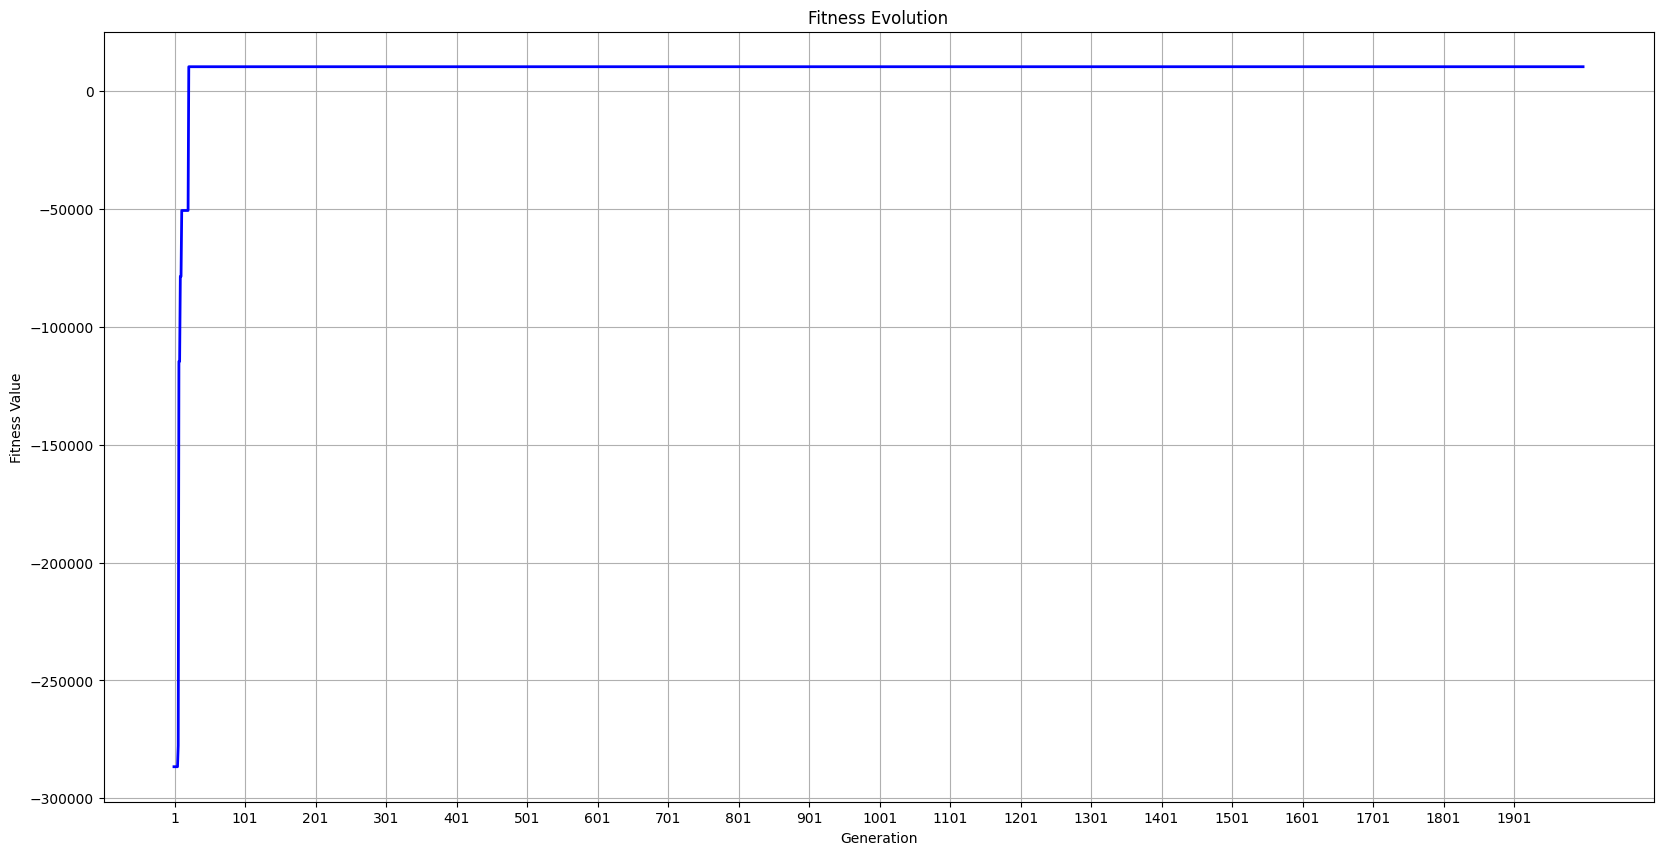

In [ ]:
import os
show_result(GENENTIC_ALG,'test10.txt')

In [ ]:
def visualization():

  population_size = [ 20, 50, 70, 100]
  generations = [500, 1000, 2000]
  mutation_rate = [0.01, 0.1, 0.2]
  cross_over_rate = [0.8, 0.9, 0.95]
  elitism_count = [ 3, 4,5]

  progress = []

  for i in population_size:
    for j in generations:
        for k in mutation_rate:
            for l in cross_over_rate:
                for m in elitism_count:
                    solver = GENENTIC_ALG('test7.txt')
                    best_assign, obj_value, elapsed_time, _ = solver.solve(
                        population_size=i,
                        generations=j,
                        mutation_rate=k,
                        cross_over_rate=l,
                        elitism_count=m
                    )
                    progress.append([i, j, k, l, m, obj_value, elapsed_time])
                    print(f"pop={i}, gen={j}, mut={k}, cross={l}, elit={m} -> val={obj_value}, time={elapsed_time:.2f}s")

  # Save results to DataFrame
  df = pd.DataFrame(progress, columns=[
    "PopulationSize", "Generations", "MutationRate", "CrossoverRate", "ElitismCount", "ObjectiveValue", "ElapsedTime"])

  df.to_csv("ga_experiment_results.csv", index=False)
  print("Results saved to ga_experiment_results(300,10).csv")


In [ ]:
visualization()

pop=20, gen=500, mut=0.01, cross=0.8, elit=3 -> val=196, time=2.18s
pop=20, gen=500, mut=0.01, cross=0.8, elit=4 -> val=777, time=1.89s
pop=20, gen=500, mut=0.01, cross=0.8, elit=5 -> val=0, time=1.13s
pop=20, gen=500, mut=0.01, cross=0.9, elit=3 -> val=317, time=1.27s
pop=20, gen=500, mut=0.01, cross=0.9, elit=4 -> val=383, time=1.23s
pop=20, gen=500, mut=0.01, cross=0.9, elit=5 -> val=737, time=1.13s
pop=20, gen=500, mut=0.01, cross=0.95, elit=3 -> val=1356, time=1.26s
pop=20, gen=500, mut=0.01, cross=0.95, elit=4 -> val=679, time=1.23s
pop=20, gen=500, mut=0.01, cross=0.95, elit=5 -> val=1417, time=1.16s
pop=20, gen=500, mut=0.1, cross=0.8, elit=3 -> val=482, time=2.20s
pop=20, gen=500, mut=0.1, cross=0.8, elit=4 -> val=0, time=2.57s
pop=20, gen=500, mut=0.1, cross=0.8, elit=5 -> val=1192, time=1.56s
pop=20, gen=500, mut=0.1, cross=0.9, elit=3 -> val=444, time=1.57s
pop=20, gen=500, mut=0.1, cross=0.9, elit=4 -> val=1200, time=1.46s
pop=20, gen=500, mut=0.1, cross=0.9, elit=5 -> val

KeyboardInterrupt: 

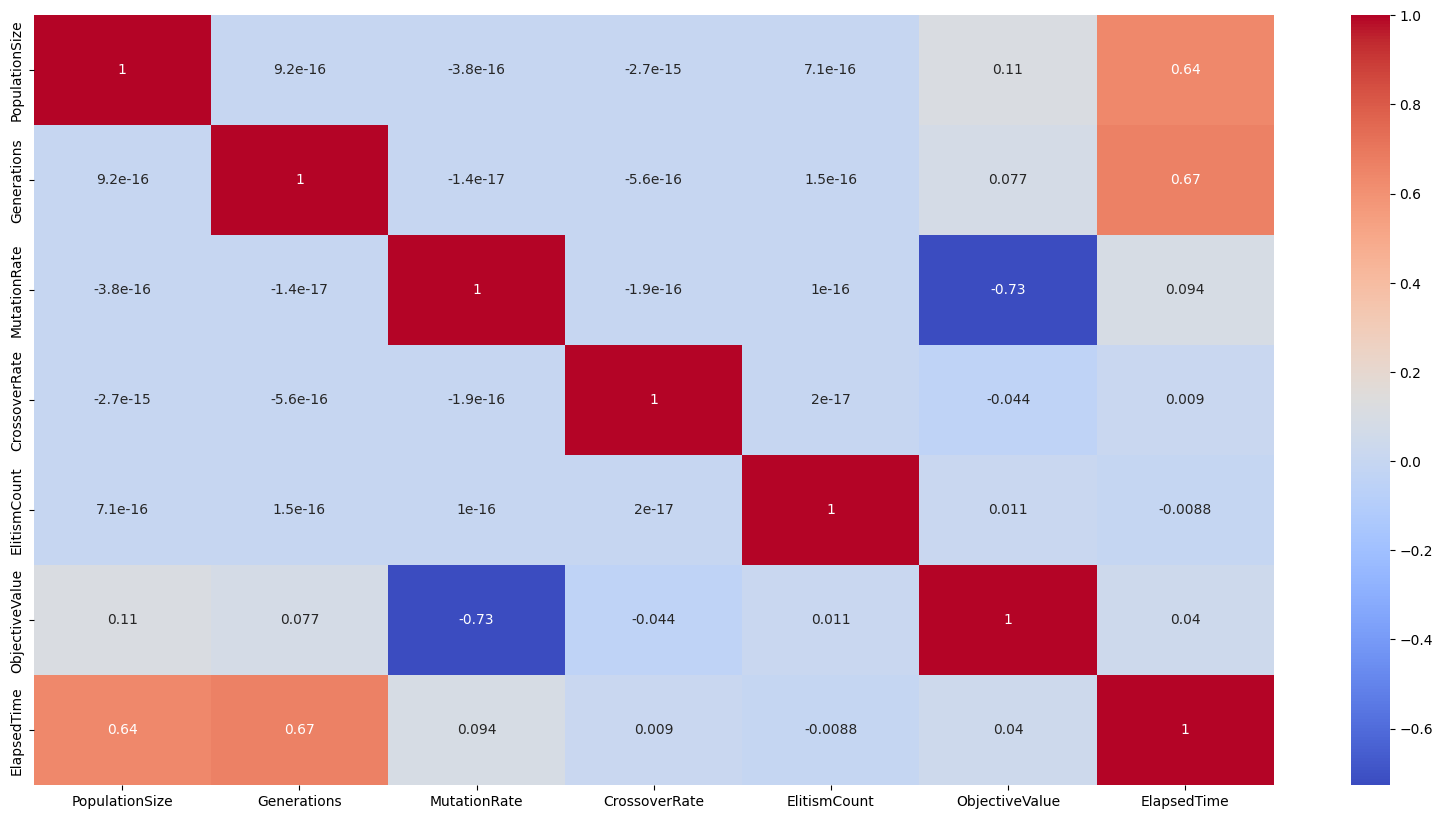

In [ ]:
df=pd.read_csv('ga_experiment_results.csv')
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

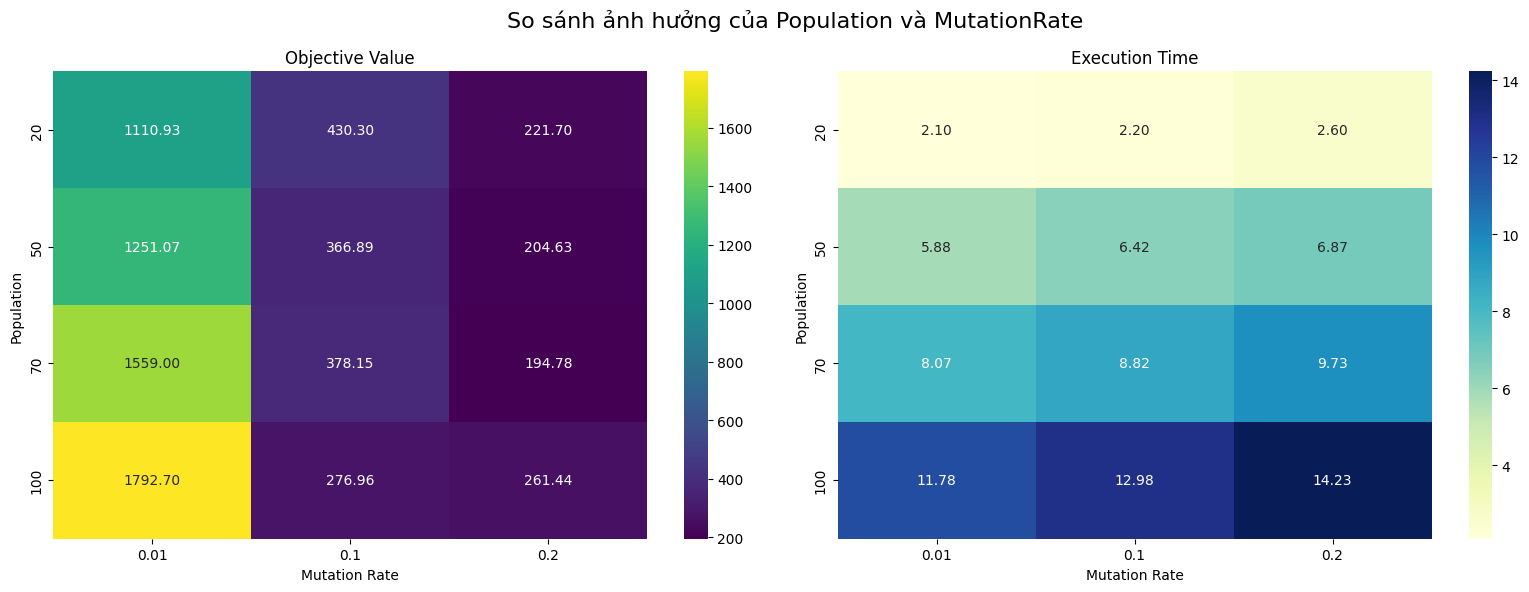

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    df.pivot_table(index="PopulationSize", columns="MutationRate", values="ObjectiveValue"),
    ax=axes[0], annot=True, fmt=".2f", cmap="viridis"
)
axes[0].set_title("Objective Value")

sns.heatmap(
    df.pivot_table(index="PopulationSize", columns="MutationRate", values="ElapsedTime"),
    ax=axes[1], annot=True, fmt=".2f", cmap="YlGnBu"
)
axes[1].set_title("Execution Time")

for ax in axes:
    ax.set_xlabel("Mutation Rate")
    ax.set_ylabel("Population")

plt.suptitle("So sánh ảnh hưởng của Population và MutationRate", fontsize=16)
plt.tight_layout()
plt.show()


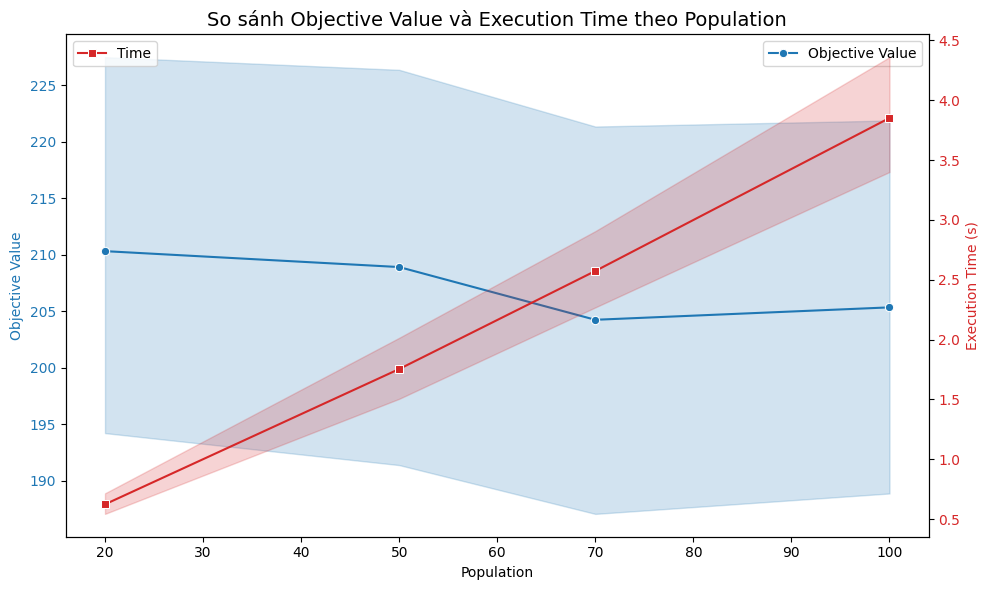

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = "tab:blue"
ax1.set_xlabel("Population")
ax1.set_ylabel("Objective Value", color=color1)
sns.lineplot(data=df, x="PopulationSize", y="ObjectiveValue", color=color1, marker="o", label="Objective Value", ax=ax1)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = "tab:red"
ax2.set_ylabel("Execution Time (s)", color=color2)
sns.lineplot(data=df, x="PopulationSize", y="ElapsedTime", color=color2, marker="s", label="Time", ax=ax2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title("So sánh Objective Value và Execution Time theo Population", fontsize=14)
fig.tight_layout()
plt.show()


In [ ]:
def evolutionary_progress():
  best_assign, obj_val, time_duration, fit_his =GENENTIC_ALG('test3.txt').solve()

  plt.figure(figsize=(7,4))
  plt.plot(fit_his, color='blue', linewidth=2)
  plt.title("Fitness Evolution")
  plt.xlabel("Generation")
  plt.ylabel("Fitness Value")
  plt.xticks(np.arange(1, len(fit_his)+1, 100))
  #ymin = min(fit_his) * 0.95
  #ymax = max(fit_his) * 1.05
  #plt.ylim(ymin,ymax)
  plt.grid(True)
  plt.show()

In [ ]:
best_assign, obj_val, time_duration, fit_his =GENENTIC_ALG('test10.txt').solve()
print(fit_his)

[-925582, -895644, -814349, -814349, -809928, -809928, -790863, -785263, -752743, -752743, -739374, -739374, -739374, -739374, -738976, -735205, -728511, -728511, -724269, -724269, -719702, -717408, -646895, -646895, -646895, -612598, -604095, -604095, -604095, -604095, -604095, -604095, -604095, -604095, -604095, -604095, -604095, -604095, -604095, -604095, -604095, -604095, -604095, -604095, -604095, -604095, -604095, -604095, -604095, -604095, -604095, -601709, -601709, -601709, -601709, -601709, -593817, -593817, -593817, -593817, -593817, -593817, -593817, -589177, -586088, -586088, -586088, -584928, -584928, -584928, -584928, -584928, -584928, -584928, -584928, -584928, -584928, -584928, -584928, -584928, -584928, -584928, -584928, -584928, -584928, -584928, -584928, -584928, -555470, -555470, -555470, -555470, -555470, -555470, -555042, -555042, -555042, -555042, -555042, -555042, -555042, -555042, -555042, -555042, -555042, -555042, -555042, -555042, -555042, -555042, -555042, 

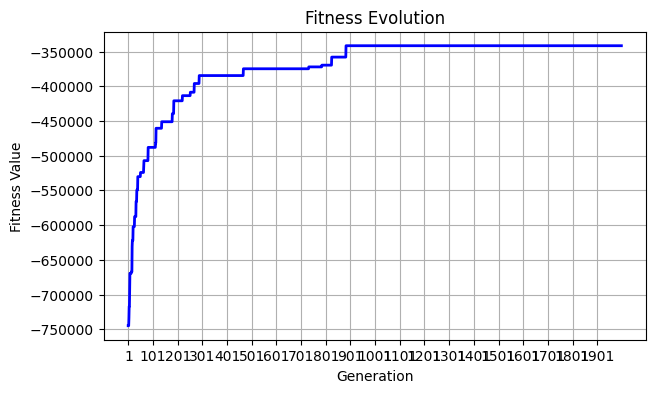

In [ ]:
evolutionary_progress()

742
1 17
2 69
3 52
4 20
5 62
6 1
7 75
8 53
9 1
10 8
11 72
12 57
13 5
14 53
15 1
16 58
17 59
18 33
19 43
20 9
21 59
22 50
23 9
24 42
25 1
26 52
27 9
28 59
29 59
30 35
31 9
32 46
33 12
34 19
36 9
37 60
38 25
39 1
40 45
41 25
42 21
43 70
44 49
45 68
46 74
47 55
48 33
49 31
50 44
51 70
52 9
53 30
54 67
55 21
56 8
57 43
58 53
59 73
60 30
61 79
62 49
63 9
64 9
65 5
66 9
67 69
69 14
70 14
72 9
74 71
75 27
76 60
77 64
78 65
79 2
80 52
81 50
82 9
83 23
84 43
85 57
86 24
87 49
88 19
89 9
90 49
91 23
93 74
94 7
95 1
96 20
97 19
98 25
99 31
100 7
101 66
102 9
103 71
104 5
105 35
106 60
107 7
108 54
109 57
110 1
111 5
112 8
113 49
114 45
115 9
116 45
117 19
118 2
119 14
121 61
122 9
123 33
124 1
125 25
126 23
127 73
128 45
129 5
130 58
131 50
132 42
133 53
134 5
135 65
136 9
137 71
138 21
140 19
141 71
142 47
143 47
144 36
146 46
147 12
148 5
149 65
151 50
152 55
153 9
154 9
155 24
157 31
158 1
159 29
162 52
163 33
164 12
165 5
166 9
167 19
168 12
169 1
170 30
171 1
172 3
173 23
174 80
175 75
176 2

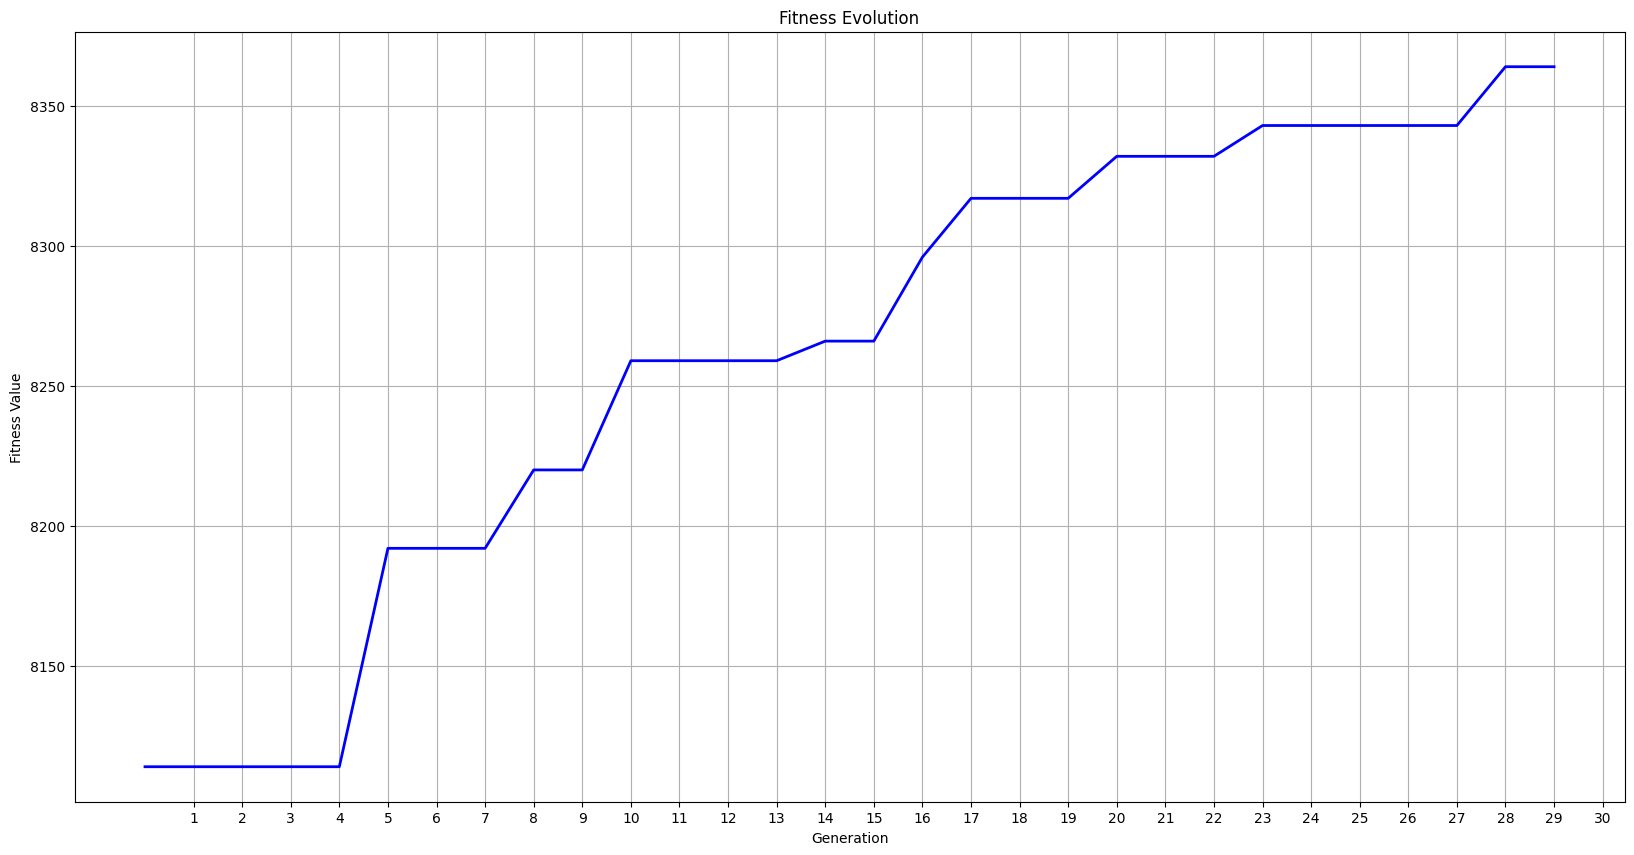

In [ ]:
import random
import math
import copy
import sys
import time
import numpy as np

sys.setrecursionlimit(2000)

class Node:
    def evaluate(self, context):
        raise NotImplementedError

    def height(self):
        raise NotImplementedError

    def size(self):
        raise NotImplementedError

    def copy(self):
        raise NotImplementedError

class Terminal(Node):
    def __init__(self, name):
        self.name = name

    def evaluate(self, context):
        return context[self.name]

    def height(self):
        return 0

    def size(self):
        return 1

    def copy(self):
        return Terminal(self.name)

    def __str__(self):
        return self.name

class Constant(Node):
    def __init__(self, value):
        self.value = value

    def evaluate(self, context):
        return self.value

    def height(self):
        return 0

    def size(self):
        return 1

    def copy(self):
        return Constant(self.value)

    def __str__(self):
        return f"{self.value:.2f}"

class Operation(Node):
    def __init__(self, func, name, left, right=None):
        self.func = func
        self.name = name
        self.left = left
        self.right = right

    def evaluate(self, context):
        if self.right is None:
             return self.func(self.left.evaluate(context))
        return self.func(self.left.evaluate(context), self.right.evaluate(context))

    def height(self):
        r_height = self.right.height() if self.right else 0
        return 1 + max(self.left.height(), r_height)

    def size(self):
        r_size = self.right.size() if self.right else 0
        return 1 + self.left.size() + r_size

    def copy(self):
        return Operation(self.func, self.name, self.left.copy(), self.right.copy() if self.right else None)

    def __str__(self):
        if self.right:
            return f"({self.left} {self.name} {self.right})"
        return f"({self.name} {self.left})"

def safe_div(a, b):
    return a / b if abs(b) > 1e-9 else 1.0

def safe_sub(a, b):
    return max(0, a - b)


class GP_ALG:
    def __init__(self, input_file=None):
        self.input_file = input_file
        self.orders_num = 0
        self.vehicles_num = 0
        self.quantity = []
        self.cost = []
        self.lower_bound = []
        self.upper_bound = []
        self.max_score = 0

        self.terminals = ['OC', 'OW', 'VR', 'VLB', 'VUB', 'VL']
        self.functions = [
            (lambda a, b: a + b, '+'),
            (lambda a, b: a - b, '-'),
            (lambda a, b: a * b, '*'),
            (safe_div, '/')
        ]

    def read_input(self, file=None):
        if file is None:
            file = self.input_file
        with open(file, 'r') as f:
            N, K = map(int, f.readline().split())
            quantity = []
            cost = []
            for _ in range(N):
                q, c = map(int, f.readline().split())
                quantity.append(q)
                cost.append(c)
            lower_bound = []
            upper_bound = []
            for _ in range(K):
                l, u = map(int, f.readline().split())
                lower_bound.append(l)
                upper_bound.append(u)
        self.orders_num = N
        self.vehicles_num = K
        self.quantity = quantity
        self.cost = cost
        self.lower_bound = lower_bound
        self.upper_bound = upper_bound
        self.max_score = sum(self.cost)

    def get_max_possible_score(self):
        return self.max_score

    def random_tree(self, depth, max_depth):
        if depth == max_depth or (depth > 0 and random.random() < 0.1):
            if random.random() < 0.8:
                return Terminal(random.choice(self.terminals))
            else:
                return Constant(random.uniform(0, 10))
        else:
            func, name = random.choice(self.functions)
            left = self.random_tree(depth + 1, max_depth)
            right = self.random_tree(depth + 1, max_depth)
            return Operation(func, name, left, right)

    def get_all_nodes(self, tree):
        nodes = [tree]
        if isinstance(tree, Operation):
            nodes.extend(self.get_all_nodes(tree.left))
            if tree.right:
                nodes.extend(self.get_all_nodes(tree.right))
        return nodes

    def replace_node(self, target_node, new_node, tree):
        if target_node == tree:
            return new_node
        if isinstance(tree, Operation):
            if tree.left == target_node:
                tree.left = new_node
            else:
                self.replace_node(target_node, new_node, tree.left)

            if tree.right == target_node:
                tree.right = new_node
            elif tree.right:
                self.replace_node(target_node, new_node, tree.right)
        return tree

    def crossover(self, parent1, parent2):
        off1 = parent1.copy()
        off2 = parent2.copy()

        nodes1 = self.get_all_nodes(off1)
        nodes2 = self.get_all_nodes(off2)

        if not nodes1 or not nodes2: return off1, off2

        node1 = random.choice(nodes1)
        node2 = random.choice(nodes2)

        subtree1 = node1.copy()
        subtree2 = node2.copy()

        off1 = self.replace_node(node1, subtree2, off1)
        off2 = self.replace_node(node2, subtree1, off2)

        return off1, off2

    def mutation(self, individual, max_depth=4):
        offspring = individual.copy()
        nodes = self.get_all_nodes(offspring)
        mutate_point = random.choice(nodes)
        new_subtree = self.random_tree(0, random.randint(1, max_depth))
        offspring = self.replace_node(mutate_point, new_subtree, offspring)
        return offspring

    def run_simulation(self, gp_tree):
        """Chạy greedy assignment với GP tree điều khiển việc chọn vehicle"""
        assignments = [-1] * self.orders_num
        veh_load = [0] * self.vehicles_num

        # Sort orders theo cost/weight ratio
        unassigned_orders = list(range(self.orders_num))
        unassigned_orders.sort(
            key=lambda i: self.cost[i] / self.quantity[i],
            reverse=True
        )

        # Greedy assign
        for order_idx in unassigned_orders:
            best_score = -float('inf')
            best_vehicle = -1

            for v_idx in range(self.vehicles_num):
                if veh_load[v_idx] + self.quantity[order_idx] <= self.upper_bound[v_idx]:
                    context = {
                        'OC': self.cost[order_idx],
                        'OW': self.quantity[order_idx],
                        'VR': self.upper_bound[v_idx] - veh_load[v_idx],
                        'VLB': self.lower_bound[v_idx],
                        'VUB': self.upper_bound[v_idx],
                        'VL': veh_load[v_idx]
                    }
                    try:
                        score = gp_tree.evaluate(context)
                        if not math.isnan(score) and not math.isinf(score):
                            if score > best_score:
                                best_score = score
                                best_vehicle = v_idx
                    except:
                        continue

            if best_vehicle != -1:
                assignments[order_idx] = best_vehicle
                veh_load[best_vehicle] += self.quantity[order_idx]

        # Constraint handling: dỡ hàng từ xe vi phạm lower bound
        valid_vehicles = [False] * self.vehicles_num
        for v in range(self.vehicles_num):
            if veh_load[v] == 0 or veh_load[v] >= self.lower_bound[v]:
                valid_vehicles[v] = True

        final_assignments = [-1] * self.orders_num
        final_cost = 0
        served_orders = 0

        for o, v in enumerate(assignments):
            if v != -1 and valid_vehicles[v]:
                final_assignments[o] = v
                final_cost += self.cost[o]
                served_orders += 1

        used_vehicles = sum(
            1 for v in range(self.vehicles_num)
            if valid_vehicles[v] and veh_load[v] > 0
        )

        # Penalty 1: Orders không serve được
        unserved_orders = self.orders_num - served_orders
        penalty_unserved = unserved_orders * (self.max_score / self.orders_num) * 0.5

        # Penalty 2: Xe vi phạm lower_bound
        violated_vehicles = sum(
            1 for v in range(self.vehicles_num)
            if 0 < veh_load[v] < self.lower_bound[v]
        )
        penalty_violation = violated_vehicles * (self.max_score / self.vehicles_num) * 0.3

        # Fitness = Revenue (final_cost) - Penalties
        fitness = final_cost - penalty_unserved - penalty_violation

        stats = {
            "served_orders": served_orders,
            "used_vehicles": used_vehicles,
            "veh_load": veh_load,
            "violated_vehicles": violated_vehicles
        }

        return fitness, final_assignments, stats

    def plot_convergence(self, fitness_history, test_filename):
        try:
            import matplotlib.pyplot as plt
            plt.figure(figsize=(20, 10))
            plt.plot(fitness_history, color='blue', linewidth=2)
            plt.title("Fitness Evolution")
            plt.xlabel("Generation")
            plt.ylabel("Fitness Value")
            plt.xticks(np.arange(1, len(fitness_history)+1))
            plt.grid(True)
            plt.show()
        except:
            pass

    def run_optimization(self, test_filename,
                        pop_size=30, generations=20,
                        tournament_size=3,
                        crossover_rate=0.8, mutation_rate=0.2,
                        max_tree_depth=6,
                        stagnation_limit=5, keep_ratio=0.2):

        print("=" * 60)
        print(f"RUNNING GP FOR {test_filename}")
        print("=" * 60)

        self.read_input(test_filename)

        # Init population
        population = []
        for _ in range(pop_size):
            population.append(self.random_tree(0, random.randint(2, max_tree_depth)))

        print(f"Initialized: {pop_size} random trees (no seeding)")

        # Tracking
        best_fitness = -float('inf')
        best_individual = None
        best_assignment = None
        best_stats = None
        fit_his = []
        stagnation_counter = 0
        last_best = -float('inf')
        restart_count = 0

        # Evolution loop
        for gen in range(generations):
            fitnesses = []

            # Evaluate
            for ind in population:
                fit, assignment, stats = self.run_simulation(ind)
                fitnesses.append(fit)

                if fit > best_fitness:
                    best_fitness = fit
                    best_individual = ind.copy()
                    best_assignment = assignment
                    best_stats = stats

            fit_his.append(best_fitness)

            if gen % 5 == 0 or gen == generations - 1:
                print(f"Gen {gen}: Best Fitness = {best_fitness:.2f}")

            # Stagnation check
            if stagnation_limit > 0:
                if best_fitness <= last_best:
                    stagnation_counter += 1
                else:
                    stagnation_counter = 0
                    last_best = best_fitness

                if stagnation_counter >= stagnation_limit:
                    restart_count += 1
                    print(f"Gen {gen}: Stagnation → Restart #{restart_count}")

                    # Keep top individuals
                    n_keep = max(1, int(pop_size * keep_ratio))
                    sorted_pop = sorted(zip(population, fitnesses), key=lambda x: x[1], reverse=True)
                    population = [ind for ind, _ in sorted_pop[:n_keep]]

                    # Ensure best individual is kept
                    if best_individual not in population:
                        population[0] = best_individual.copy()

                    while len(population) < pop_size:
                        population.append(self.random_tree(0, random.randint(2, max_tree_depth)))

                    stagnation_counter = 0
                    continue

            # Create next generation with ELITISM
            next_population = [best_individual.copy()]

            while len(next_population) < pop_size:
                # Tournament selection
                p1 = max(random.sample(list(zip(population, fitnesses)), tournament_size), key=lambda x: x[1])[0]
                p2 = max(random.sample(list(zip(population, fitnesses)), tournament_size), key=lambda x: x[1])[0]

                # Crossover
                if random.random() < crossover_rate:
                    c1, c2 = self.crossover(p1, p2)
                else:
                    c1, c2 = p1.copy(), p2.copy()

                # Mutation
                if random.random() < mutation_rate:
                    c1 = self.mutation(c1, max_tree_depth)
                if random.random() < mutation_rate:
                    c2 = self.mutation(c2, max_tree_depth)

                next_population.extend([c1, c2])

            population = next_population[:pop_size]

        # Summary
        print("\n" + "=" * 60)
        print("SOLUTION SUMMARY")
        print("=" * 60)
        print(f"Orders served: {best_stats['served_orders']}/{self.orders_num}")
        print(f"Vehicles used: {best_stats['used_vehicles']}/{self.vehicles_num}")
        print(f"Objective Value: {best_fitness:.2f}")
        print(f"Max possible: {self.max_score}")
        print(f"Restarts: {restart_count}")
        print("=" * 60 + "\n")

        self.plot_convergence(fit_his, test_filename)

        return best_assignment, best_fitness

    def solve(self, pop_size=30, generations=20, tournament_size=3,
              crossover_rate=0.8, mutation_rate=0.2, max_tree_depth=6,
              stagnation_limit=5, keep_ratio=0.2):
        """
        Version for tuning - returns real objective value
        """
        start_time = time.time()

        if self.orders_num == 0:
            self.read_input()

        # Init population
        population = []
        for _ in range(pop_size):
            population.append(self.random_tree(0, random.randint(2, max_tree_depth)))

        # Tracking
        best_fitness = -float('inf')
        best_individual = None
        best_assignment = None
        best_stats = None
        fit_his = []
        stagnation_counter = 0
        last_best = -float('inf')

        # Evolution loop
        for _ in range(generations):
            fitnesses = []

            # Evaluate
            for ind in population:
                fit, assignment, stats = self.run_simulation(ind)
                fitnesses.append(fit)

                if fit > best_fitness:
                    best_fitness = fit
                    best_individual = ind.copy()
                    best_assignment = assignment
                    best_stats = stats

            fit_his.append(best_fitness)

            # Stagnation
            if stagnation_limit > 0:
                if best_fitness <= last_best:
                    stagnation_counter += 1
                else:
                    stagnation_counter = 0
                    last_best = best_fitness

                if stagnation_counter >= stagnation_limit:
                    n_keep = max(1, int(pop_size * keep_ratio))
                    sorted_pop = sorted(zip(population, fitnesses), key=lambda x: x[1], reverse=True)
                    population = [ind for ind, _ in sorted_pop[:n_keep]]

                    if best_individual not in population:
                        population[0] = best_individual.copy()

                    while len(population) < pop_size:
                        population.append(self.random_tree(0, random.randint(2, max_tree_depth)))

                    stagnation_counter = 0
                    continue

            # Next generation with ELITISM
            next_population = [best_individual.copy()]

            while len(next_population) < pop_size:
                p1 = max(random.sample(list(zip(population, fitnesses)), tournament_size), key=lambda x: x[1])[0]
                p2 = max(random.sample(list(zip(population, fitnesses)), tournament_size), key=lambda x: x[1])[0]

                if random.random() < crossover_rate:
                    c1, c2 = self.crossover(p1, p2)
                else:
                    c1, c2 = p1.copy(), p2.copy()

                if random.random() < mutation_rate:
                    c1 = self.mutation(c1, max_tree_depth)
                if random.random() < mutation_rate:
                    c2 = self.mutation(c2, max_tree_depth)

                next_population.extend([c1, c2])

            population = next_population[:pop_size]

        time_taken = time.time() - start_time

        objective_value = sum(
            self.cost[i] for i in range(self.orders_num)
            if best_assignment[i] != -1
        )

        return (
            best_assignment,
            objective_value,
            time_taken,
            fit_his,
            self.max_score,
            best_stats
        )

995
1 78
2 99
3 99
4 41
5 25
6 65
7 62
8 28
9 51
10 2
11 81
12 2
13 67
14 38
15 38
16 51
17 44
18 7
19 81
20 68
21 69
22 91
23 27
24 28
25 26
26 74
27 81
28 41
29 28
30 15
31 51
32 11
33 84
34 67
35 91
36 76
37 51
38 11
39 44
40 33
41 94
42 1
43 89
44 2
45 38
46 7
47 2
48 46
49 15
50 79
51 11
52 1
53 51
54 18
55 43
56 68
57 6
58 2
59 98
60 2
61 61
62 81
63 49
64 16
65 51
66 38
67 6
68 28
69 91
70 74
71 91
72 16
73 91
74 11
75 11
76 74
77 28
78 41
79 11
80 65
81 28
82 4
83 13
84 58
85 62
86 4
87 13
88 57
89 98
90 68
91 59
92 7
93 34
94 16
95 23
96 95
97 31
98 53
99 2
100 26
101 78
102 37
103 16
104 13
105 26
106 69
107 69
108 98
109 26
110 98
111 63
112 2
113 99
114 41
115 31
116 49
117 27
118 78
119 13
120 68
121 62
122 7
123 53
124 11
125 81
126 95
127 9
128 12
129 54
130 62
131 62
132 7
133 98
134 34
135 49
136 82
137 90
138 88
139 91
140 69
141 1
142 13
143 53
144 74
145 4
146 82
147 7
148 49
149 4
150 82
151 12
152 4
153 62
154 19
155 17
156 41
157 100
158 26
159 41
160 34
161 100


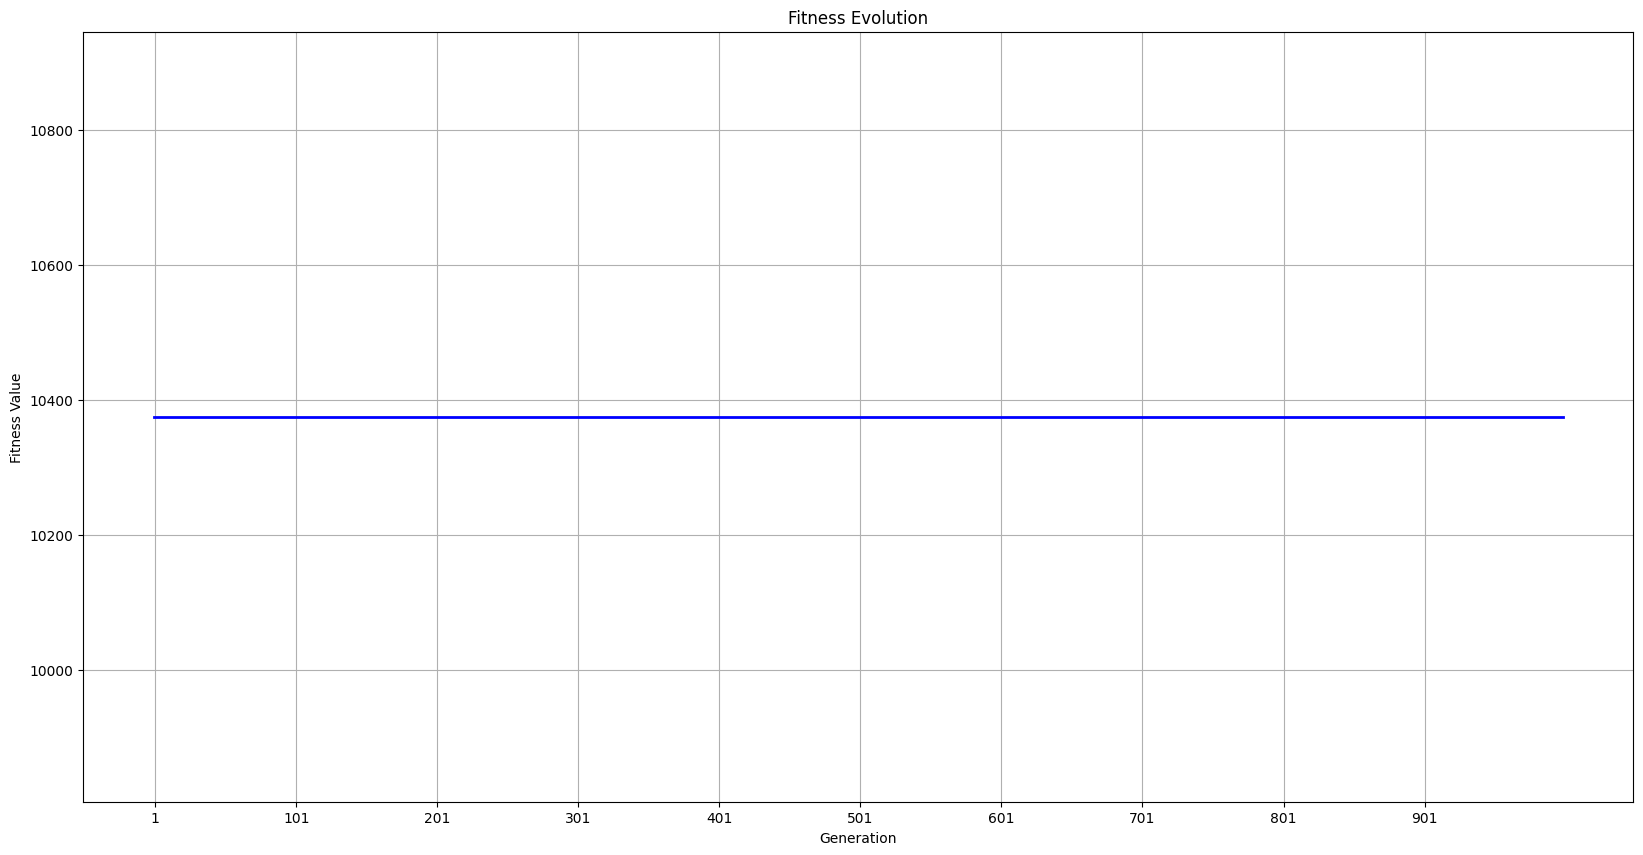

In [ ]:
import random
import time
import sys

@jit(nopython=True)
def fast_calculate_fitness(individual, quantity, cost, lower_bound, upper_bound, vehicles_num):
    # Khởi tạo mảng load với kiểu số nguyên
    veh_load = np.zeros(vehicles_num, dtype=np.int32)
    total_cost = 0
    penalty = 0

    # Vòng lặp tính tải trọng và chi phí cơ bản
    # Numba sẽ tự động tối ưu vòng lặp này (Loop Unrolling, Vectorization)
    n = len(individual)
    for i in range(n):
        vehicle_idx = individual[i]
        if vehicle_idx != -1:
            veh_load[vehicle_idx] += quantity[i]
            total_cost += cost[i]

    # Vòng lặp tính Penalty
    for v_idx in range(vehicles_num):
        load = veh_load[v_idx]

        # Nếu xe không chở gì thì bỏ qua
        if load == 0:
            continue

        # Kiểm tra tải trọng (Logic check_validation được gộp vào đây)
        if load < lower_bound[v_idx]:
            penalty += (lower_bound[v_idx] - load) * 1000
        elif load > upper_bound[v_idx]:
            penalty += (load - upper_bound[v_idx]) * 1000

    return total_cost - penalty
class EVOLUTIONARY_PROGRAMMING:
    def __init__(self, input_file=None):
        self.input_file = input_file

    def read_input(self, file=None):
        if file is None:
            file = self.input_file

        # Handle case where file is not provided (read from stdin)
        if file:
            try:
                with open(file, 'r') as f:
                    lines = f.read().split()
            except FileNotFoundError:
                print(f"Error: File '{file}' not found.")
                sys.exit(1)
        else:
            # Read all from stdin
            lines = sys.stdin.read().split()

        iterator = iter(lines)
        try:
            N = int(next(iterator))
            K = int(next(iterator))
            quantity = []
            cost = []
            for _ in range(N):
                quantity.append(int(next(iterator)))
                cost.append(int(next(iterator)))
            lower_bound = []
            upper_bound = []
            for _ in range(K):
                lower_bound.append(int(next(iterator)))
                upper_bound.append(int(next(iterator)))

            self.orders_num = N
            self.vehicles_num = K
            self.quantity = quantity
            self.cost = cost
            self.lower_bound = lower_bound
            self.upper_bound = upper_bound

            self.np_quantity = np.array(quantity, dtype=np.int32)
            self.np_cost = np.array(cost, dtype=np.int32)
            self.np_lower = np.array(lower_bound, dtype=np.int32)
            self.np_upper = np.array(upper_bound, dtype=np.int32)
        except StopIteration:
            pass

    def check_validation(self, load, v_idx):
        if load == 0:
            return True
        return self.lower_bound[v_idx] <= load <= self.upper_bound[v_idx]

    '''def fitness_calculated(self, individual):
        cost = 0
        load = [0] * self.vehicles_num
        penalty = -1000
        punish_score = 0
        for order_idx, vehicle_idx in enumerate(individual):
            if vehicle_idx != -1:
                load[vehicle_idx] += self.quantity[order_idx]
                cost += self.cost[order_idx]
        for vehicle_idx, l in enumerate(load):
            if not self.check_validation(l, vehicle_idx):
                if l > self.upper_bound[vehicle_idx]:
                    punish_score += (l - self.upper_bound[vehicle_idx]) * penalty
                elif l > 0 and l < self.lower_bound[vehicle_idx]:
                    punish_score += (self.lower_bound[vehicle_idx] - l) * penalty
        return cost + punish_score'''

    def fitness_calculated(self, individual):
        # Chuyển cá thể hiện tại sang numpy array (chi phí chuyển đổi rất nhỏ)
        ind_np = np.array(individual, dtype=np.int32)

        # Gọi hàm đã được biên dịch bởi Numba
        return fast_calculate_fitness(
            ind_np,
            self.np_quantity,
            self.np_cost,
            self.np_lower,
            self.np_upper,
            self.vehicles_num
        )

    '''def repair_solution(self, individual):
        load = [0] * self.vehicles_num
        assignments = individual[:]
        curr_cost = 0
        for order_idx, vehicle_idx in enumerate(individual):
            if vehicle_idx != -1:
              load[vehicle_idx] += self.quantity[order_idx]
              curr_cost += self.cost[order_idx]
        for v_idx in range(self.vehicles_num):
            if not self.check_validation(load[v_idx], v_idx):
                for order_idx, veh_idx in enumerate(individual):
                    if veh_idx == v_idx:
                        assignments[order_idx] = -1
                        curr_cost -= self.cost[order_idx]
        return assignments, curr_cost'''
    def repair_solution(self, individual):
        load = [0] * self.vehicles_num
        assignments = individual[:]
        curr_cost = 0
        lower_bound_violated = []
        upper_bound_violated = []
        unassign_orders = []
        #Adaptive repair
        for order_idx, vehicle_idx in enumerate(individual):
            if vehicle_idx != -1:
                load[vehicle_idx] += self.quantity[order_idx]
                curr_cost += self.cost[order_idx]
            else:
                unassign_orders.append(order_idx)
        for v_id in range(self.vehicles_num):
            if load[v_id]< self.lower_bound[v_id]:
                lower_bound_violated.append(v_id)
            elif load[v_id] > self.upper_bound[v_id]:
                upper_bound_violated.append(v_id)
        for v_id in upper_bound_violated:
            while load[v_id] > self.upper_bound[v_id]:
                for order_idx, veh_idx in enumerate(individual):
                    if veh_idx == v_id and random.random()<0.5:
                        assignments[order_idx] = -1
                        curr_cost -= self.cost[order_idx]
                        load[v_id] -= self.quantity[order_idx]
                        unassign_orders.append(order_idx)
        for v_id in lower_bound_violated:
            #try_time = 0
            #while load[v_id] < self.lower_bound[v_id] and try_time < 10:
                #try_time += 1
            for order_idx, veh_idx in enumerate(individual):
                if veh_idx == v_id:
                    assignments[order_idx] = -1
                    curr_cost -= self.cost[order_idx]
                    load[v_id] -= self.quantity[order_idx]

        return assignments, curr_cost

    def greedy(self, sorted_orders: str = "cost", sorted_vehicles: str = "lower_bound"):
        load = [0] * self.vehicles_num
        assignments = [-1] * self.orders_num
        orders_rate = []
        vehicle_rate = []
        curr_cost = 0

        if sorted_orders == "cost":
            for idx, cost in enumerate(self.cost):
                orders_rate.append((idx, cost))
        elif sorted_orders == "weight":
            for idx, weight in enumerate(self.quantity):
                orders_rate.append((idx, weight))
        elif sorted_orders == "ratio":
            for idx, (weight, cost) in enumerate(zip(self.quantity, self.cost)):
                if weight == 0: weight = 1 # Avoid division by zero
                orders_rate.append((idx, cost / weight))

        orders_rate.sort(key=lambda x: x[1], reverse=True)

        if sorted_vehicles == "lower_bound":
            for idx, lower in enumerate(self.lower_bound):
                vehicle_rate.append((idx, -lower))
        elif sorted_vehicles == "upper_bound":
            for idx, upper in enumerate(self.upper_bound):
                vehicle_rate.append((idx, -upper))
        elif sorted_vehicles == "range":
            for idx, (lower, upper) in enumerate(zip(self.lower_bound, self.upper_bound)):
                vehicle_rate.append((idx, upper - lower))
        vehicle_rate.sort(key=lambda x: x[1])

        for ord_idx, _ in orders_rate:
            for veh_idx, _ in vehicle_rate:
                if load[veh_idx] + self.quantity[ord_idx] <= self.upper_bound[veh_idx]:
                    assignments[ord_idx] = veh_idx
                    load[veh_idx] += self.quantity[ord_idx]
                    curr_cost += self.cost[ord_idx]
                    break

        # Greedy might violate lower bounds, clean it up
        for v_idx in range(self.vehicles_num):
            if load[v_idx] > 0 and load[v_idx] < self.lower_bound[v_idx]:
                for ord_idx, veh_idx in enumerate(assignments):
                    if veh_idx == v_idx:
                        assignments[ord_idx] = -1
                        curr_cost -= self.cost[ord_idx]
                load[v_idx] = 0
        return assignments, curr_cost, load
    def get_max_possible_score(self):
        return sum(self.cost)
    def create_initial_population(self, population_size):
        population = []
        vehicle_sorted_order = ['lower_bound', 'upper_bound', 'range']
        order_sorted_order = ['cost', 'weight', 'ratio']

        for _ in range(population_size):
            ord_sort = random.choice(order_sorted_order)
            veh_sort = random.choice(vehicle_sorted_order)
            individual, _, _ = self.greedy(ord_sort, veh_sort)
            population.append(individual)

        # Add random noise to initial greedy solutions
        for ind in population:
            num_changes = random.randint(0, self.orders_num // 5) # Limit noise
            change_indices = [random.randint(0, self.orders_num - 1) for _ in range(num_changes)]
            for i in change_indices:
                v_id = random.randint(-1, self.vehicles_num - 1)
                ind[i] = v_id
        return population
        '''
    def create_initial_population(self, population_size):
        #initalizie population by using greedy
        population = []
        sorted_orders = ["cost", "weight", "ratio"]
        sorted_vehicles = ["lower_bound", "upper_bound", "range"]
        greedy_size = 0
        load = []
        for _ in range(greedy_size):
            individual, _, load = self.greedy(random.choice(sorted_orders), random.choice(sorted_vehicles))
            population.append(individual)

        for _ in range(population_size - greedy_size):
            individual = []
            for order_idx in range(self.orders_num):
                vehicle_idx = random.randint(-1, self.vehicles_num - 1)
                individual.append(vehicle_idx)
            population.append(individual)
        return population'''
    def mutation(self, individual, mutation_rate=0.01):
        for i in range(self.orders_num):
            if random.random() < mutation_rate:
                diff = 0
                while not diff:
                  new_vid = random.randint(-1, self.vehicles_num - 1)
                  if new_vid != individual[i]:
                    diff = 1
                    individual[i] = new_vid
        return individual
    def mutation_swap(self, individual, mutation_rate):
        if random.random() < mutation_rate:
            swap_count = random.randint(1, max(1, self.orders_num // 10))
            for _ in range(swap_count):
                idx1, idx2 = random.sample(range(self.orders_num), 2)
                individual[idx1], individual[idx2] = individual[idx2], individual[idx1]
        return individual

    def mutation_add(self, individual, mutation_rate):
        if random.random() < mutation_rate:
            load = [0] * self.vehicles_num
            for order_idx, vehicle_idx in enumerate(individual):
                if vehicle_idx != -1:
                    load[vehicle_idx] += self.quantity[order_idx]

            unassigned_orders = [i for i, v in enumerate(individual) if v == -1]
            if unassigned_orders:
                # Try to assign a subset of unassigned orders
                order_idxs = random.sample(unassigned_orders, random.randint(1, len(unassigned_orders)))
                for idx in order_idxs:
                    attempts = 0
                    done = 0
                    # Added attempts check to prevent infinite loop
                    while not done and attempts < 10:
                        vehicle_idx = random.randint(0, self.vehicles_num - 1)
                        if load[vehicle_idx] + self.quantity[idx] <= self.upper_bound[vehicle_idx]:
                            individual[idx] = vehicle_idx
                            load[vehicle_idx] += self.quantity[idx]
                            done = 1
                        attempts += 1
        return individual

    def mutation_remove(self, individual, mutation_rate):
        if random.random() < mutation_rate:
            load = [0] * self.vehicles_num
            for order_idx, vehicle_idx in enumerate(individual):
                if vehicle_idx != -1:
                    load[vehicle_idx] += self.quantity[order_idx]

            overloaded_vehicles = [i for i, v in enumerate(load) if v > self.upper_bound[i]]
            underload_vehicles = [i for i, v in enumerate(load) if v > 0 and v < self.lower_bound[i]] # Prioritize fixing actual underloads

            # If no strictly underloaded vehicles, consider any valid vehicle
            if not underload_vehicles:
                underload_vehicles = [i for i in range(self.vehicles_num)]

            for v_id in overloaded_vehicles:
                order_idxs = [i for i, v in enumerate(individual) if v == v_id]
                if not order_idxs: continue

                attempts = 0
                # Try to move orders until vehicle is no longer overloaded or attempts run out
                while load[v_id] > self.upper_bound[v_id] and attempts < 20:
                    order_idx = random.choice(order_idxs)
                    sub_attempts = 0
                    done = 0
                    while not done and sub_attempts < 10:
                        if not underload_vehicles: break
                        new_v_id = random.choice(underload_vehicles)

                        # Ensure we don't just move it to another overloaded vehicle
                        if load[new_v_id] + self.quantity[order_idx] <= self.upper_bound[new_v_id]:
                            done = 1
                            individual[order_idx] = new_v_id
                            load[new_v_id] += self.quantity[order_idx]
                            load[v_id] -= self.quantity[order_idx]
                            # Remove from list if moved
                            order_idxs.remove(order_idx)
                        sub_attempts += 1
                    attempts += 1
        return individual

    def selection(self, org_population, new_gen_population, tourment_size=3):
        tourment_id = random.sample(range(len(org_population)), tourment_size)
        tourment = []
        for i in tourment_id:
            if org_population[i][1] > new_gen_population[i][1]:
                tourment.append(org_population[i])
            else:
                tourment.append(new_gen_population[i])

        tourment = sorted(tourment, key=lambda x: x[1], reverse=True)
        return tourment[0][0][:]

    def solve(self, population_size=100, generations=1000, mutation_rate= 1, elitism_count=3):
        self.read_input()
        population = self.create_initial_population(population_size)
        best_individual = None
        max_score = self.get_max_possible_score()
        best_fitness = -float('inf')
        time_start = time.time()
        fit_his = []
        for gen in range(generations):
            fitness = [self.fitness_calculated(ind) for ind in population]
            sorted_population = sorted(zip(population, fitness), key=lambda x: x[1], reverse=True)

            if sorted_population[0][1] > best_fitness:
                best_fitness = sorted_population[0][1]
                best_individual = sorted_population[0][0][:]

            new_population = []
            fit_his.append(best_fitness)
            # Elitism
            for i in range(elitism_count):
                new_population.append(sorted_population[i][0][:])
            population_left = sorted_population[elitism_count:]
            off_springs = []

            # Iterate over population_left
            for individual, fit in population_left:
                ind_copy = individual[:] # Copy before mutating

                mutation_method = random.choice(['explore','swap', 'remove', 'add'])

                if mutation_method == 'swap':
                    off_spring = self.mutation_swap(ind_copy, mutation_rate)
                elif mutation_method == 'remove':
                    off_spring = self.mutation_remove(ind_copy, mutation_rate)
                elif mutation_method == 'add':
                    off_spring = self.mutation_add(ind_copy, mutation_rate)
                elif mutation_method == 'explore':
                    off_spring = self.mutation(ind_copy, mutation_rate)

                off_springs.append(off_spring)

            off_springs_fitness = [self.fitness_calculated(ind) for ind in off_springs]
            calculated_off_springs = list(zip(off_springs, off_springs_fitness))

            # Tournament Selection to fill the rest of the population
            while len(new_population) < population_size:
                winner = self.selection(population_left, calculated_off_springs)
                new_population.append(winner)

            population = new_population

        time_duration = time.time() - time_start

        if best_individual is None and population:
            best_individual = population[0]

        final_assignment, final_cost = self.repair_solution(best_individual)

        return final_assignment, final_cost, time_duration, fit_his, max_score

def main():
    solver = EVOLUTIONARY_PROGRAMMING('test10.txt')

    best_assignment, objective_value, time_taken, fit_his, max_score = solver.solve()

    best_served_orders = [(i + 1, v + 1) for i, v in enumerate(best_assignment) if v != -1]

    # Final Output
    print(len(best_served_orders))
    for order_idx, vehicle_idx in best_served_orders:
        print(f"{order_idx} {vehicle_idx}")
    print(f"Objective Value: {objective_value}, Time taken: {time_taken:.2f} seconds")
    print(fit_his)
    plt.figure(figsize=(20,10))
    plt.plot(fit_his, color='blue', linewidth=2)
    plt.title("Fitness Evolution")
    plt.xlabel("Generation")
    plt.ylabel("Fitness Value")
    plt.xticks(np.arange(1, len(fit_his)+1, 100))
    #ymin = min(fit_his) * 0.95
    #ymax = max(fit_his) * 1.05
    #plt.ylim(ymin,ymax)
    plt.grid(True)
    plt.show()
if __name__ == "__main__":
    main()

In [ ]:
#Adaptive_ES
import random
import time
import sys
import cma

class EVOLUTIONARY_STRATEGY:
    def __init__(self, input_file=None):
        self.input_file = input_file
    '''def read_input(self):
        N, K = map(int, input().split())
        quantity = []
        cost = []
        for _ in range(N):
            q, c = map(int, input().split())
            quantity.append(q)
            cost.append(c)
        lower_bound = []
        upper_bound = []
        for _ in range(K):
            l, u = map(int, input().split())
            lower_bound.append(l)
            upper_bound.append(u)
        self.orders_num = N
        self.vehicles_num = K
        self.quantity = quantity
        self.cost = cost
        self.lower_bound = lower_bound
        self.upper_bound = upper_bound'''
    def read_input(self, file = None):
        if file is None:
            file = self.input_file
        with open(file, 'r') as f:
            N, K = map(int, f.readline().split())
            quantity = []
            cost = []
            for _ in range(N):
                q, c = map(int, f.readline().split())
                quantity.append(q)
                cost.append(c)
            lower_bound = []
            upper_bound = []
            for _ in range(K):
                l, u = map(int, f.readline().split())
                lower_bound.append(l)
                upper_bound.append(u)
        self.orders_num = N
        self.vehicles_num = K
        self.quantity = quantity
        self.cost = cost
        self.lower_bound = lower_bound
        self.upper_bound = upper_bound
    def get_max_possible_score(self):
        return sum(self.cost)
    def check_validation(self, load, v_idx):
        if load == 0:
            return True
        return self.lower_bound[v_idx] <= load <= self.upper_bound[v_idx]

    def calculate_fitness(self, individual):
        cost=0
        veh_load = [0] * self.vehicles_num
        penalty = 0
        for order_idx, vehicle_idx in enumerate(individual):
            if vehicle_idx != -1:
                veh_load[vehicle_idx] += self.quantity[order_idx]
                cost += self.cost[order_idx]
        for vehicle_idx, load in enumerate(veh_load):
            if self.check_validation(load,vehicle_idx):
                continue
            else:
                if load > self.upper_bound[vehicle_idx]:
                    penalty += (load-self.upper_bound[vehicle_idx])*1000
                elif load >0 and load < self.lower_bound[vehicle_idx]:
                    penalty += (self.lower_bound[vehicle_idx]-load)*1000

        return cost - penalty

    def repair_solution(self, individual):
        load = [0] * self.vehicles_num
        assignments = individual[:]
        curr_cost = 0
        lower_bound_violated = []
        upper_bound_violated = []
        unassign_orders = []
        #Adaptive repair
        for order_idx, vehicle_idx in enumerate(individual):
            if vehicle_idx != -1:
                load[vehicle_idx] += self.quantity[order_idx]
                curr_cost += self.cost[order_idx]
            else:
                unassign_orders.append(order_idx)
        for v_id in range(self.vehicles_num):
            if load[v_id]< self.lower_bound[v_id]:
                lower_bound_violated.append(v_id)
            elif load[v_id] > self.upper_bound[v_id]:
                upper_bound_violated.append(v_id)
        for v_id in upper_bound_violated:
            while load[v_id] > self.upper_bound[v_id]:
                for order_idx, veh_idx in enumerate(individual):
                    if veh_idx == v_id and random.random()<0.5:
                        assignments[order_idx] = -1
                        curr_cost -= self.cost[order_idx]
                        load[v_id] -= self.quantity[order_idx]
                        unassign_orders.append(order_idx)
        for v_id in lower_bound_violated:
            #try_time = 0
            #while load[v_id] < self.lower_bound[v_id] and try_time < 10:
                #try_time += 1
            for order_idx, veh_idx in enumerate(individual):
                if veh_idx == v_id:
                    assignments[order_idx] = -1
                    curr_cost -= self.cost[order_idx]
                    load[v_id] -= self.quantity[order_idx]

        return assignments, curr_cost

    def greedy(self, sorted_orders: str ="cost", sorted_vehicles: str = "lower_bound"):
        load = [0] * self.vehicles_num
        assignments = [-1] * self.orders_num
        orders_rate = []
        vehicle_rate = []
        curr_cost = 0
        if sorted_orders == "cost":
            for idx, cost in enumerate(self.cost):
                orders_rate.append((idx, cost))
        elif sorted_orders == "weight":
            for idx, weight in enumerate(self.quantity):
                orders_rate.append((idx, weight))
        elif sorted_orders == "ratio":
            for idx, (weight, cost) in enumerate(zip(self.quantity, self.cost)):
                orders_rate.append((idx, cost / weight))
        orders_rate.sort(key=lambda x: x[1], reverse=True)
        if sorted_vehicles == "lower_bound":
            for idx, lower in enumerate(self.lower_bound):
                vehicle_rate.append((idx, -lower))
        elif sorted_vehicles == "upper_bound":
            for idx, upper in enumerate(self.upper_bound):
                vehicle_rate.append((idx, -upper))
        elif sorted_vehicles == "range":
            for idx, (lower, upper) in enumerate(zip(self.lower_bound, self.upper_bound)):
                vehicle_rate.append((idx, upper - lower))
        vehicle_rate.sort(key=lambda x: x[1])

        for ord_idx, _ in orders_rate:
            for veh_idx, _ in vehicle_rate:
                if load[veh_idx] + self.quantity[ord_idx] <= self.upper_bound[veh_idx]:
                    assignments[ord_idx] = veh_idx
                    load[veh_idx] += self.quantity[ord_idx]
                    curr_cost += self.cost[ord_idx]
                    break
        for v_idx in range(self.vehicles_num):
            if load[v_idx] > 0 and load[v_idx] < self.lower_bound[v_idx]:
                for ord_idx, veh_idx in enumerate(assignments):
                    if veh_idx == v_idx:
                        assignments[ord_idx] = -1
                        curr_cost -= self.cost[ord_idx]
                load[v_idx] = 0
        return assignments, curr_cost, load
    def decode(self, continuous_vector):
        discrete_individual = []
        for val in continuous_vector:
            v = int(round(val))
            if -1 <= v <= self.vehicles_num - 1:
                discrete_individual.append(v)
            else:
                discrete_individual.append(-1) # Default to unassigned if outside range
        return discrete_individual
    def solve_with_cmaes(self, generations=500):
        self.read_input()
        greedy_start_solution, _, _ = self.greedy()
        start_point = [0.0] * self.orders_num
        fit_his = []
        # Initial step size (how big of a "jump" to take)
        sigma = 0.5

        # Set up the CMA-ES solver
        es = cma.CMAEvolutionStrategy(start_point, sigma, {'popsize_factor': 2})

        print(f"--- Running CMA-ES with {es.popsize} offspring per generation ---")
        time_start = time.time()
        best_individual_ever = None
        best_fitness_ever = -float('inf')

        def cma_fitness_wrapper(continuous_vector):
            '''discrete_individual = []
            for val in continuous_vector:
                rounded_val = int(round(val))
                clamped_val = max(-1, min(self.vehicles_num - 1, rounded_val))
                discrete_individual.append(clamped_val)'''
            discrete_individual = []
            for val in continuous_vector:
                v = int(round(val))
                if -1 <= v <= self.vehicles_num - 1:
                    discrete_individual.append(v)
                else:
                    discrete_individual.append(-1) # Default to unassigned if outside range

            fitness = self.calculate_fitness(discrete_individual)
            return -fitness

        gen = 0
        while not es.stop() and gen < generations:
            # "Ask" for a new population of continuous solutions
            solutions_continuous = es.ask()

            # Evaluate each one using our wrapper
            fitness_scores = [cma_fitness_wrapper(x) for x in solutions_continuous]

            # "Tell" the results back to the optimizer
            # It will use this to update its mean and covariance matrix
            es.tell(solutions_continuous, fitness_scores)

            # We must keep track of the *best discrete solution* we've seen
            best_fitness_in_gen = -min(fitness_scores)
            if best_fitness_in_gen > best_fitness_ever:
                best_fitness_ever = best_fitness_in_gen
                # Find the continuous solution that gave this fitness
                best_cont_solution = solutions_continuous[fitness_scores.index(min(fitness_scores))]
                best_individual_ever = self.decode(best_cont_solution)
            fit_his.append(best_fitness_ever)
            if gen % 10 == 0:
                print(f"Gen {gen}: Best Fitness = {best_fitness_ever}")

            gen += 1

        time_duration = time.time() - time_start

        # 4. Get the final result
        final_assignment, final_cost = self.repair_solution(best_individual_ever)

        print(f"--- CMA-ES Finished ---")
        return final_assignment, final_cost, time_duration, fit_his

def main():
    solver = EVOLUTIONARY_STRATEGY('test10.txt')

    best_assignment, objective_value, time_taken, fit_his = solver.solve_with_cmaes()

    best_served_orders = [(i + 1, v + 1) for i, v in enumerate(best_assignment) if v != -1]

    # Final Output
    print(len(best_served_orders))
    for order_idx, vehicle_idx in best_served_orders:
        print(f"{order_idx} {vehicle_idx}")
    print(f"Objective Value: {objective_value}, Time taken: {time_taken:.2f} seconds")
    print(fit_his)
    plt.figure(figsize=(20,10))
    plt.plot(fit_his, color='blue', linewidth=2)
    plt.title("Fitness Evolution")
    plt.xlabel("Generation")
    plt.ylabel("Fitness Value")
    plt.xticks(np.arange(1, len(fit_his)+1))
    # ymin = min(fit_his) * 0.95
    #ymax = max(fit_his) * 1.05
    #plt.ylim(ymin,ymax)
    plt.grid(False)
    plt.show()
if __name__ == "__main__":
    main()

ModuleNotFoundError: No module named 'cma'

In [ ]:
pip install cma

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.5/309.5 kB 6.2 MB/s eta 0:00:00


In [ ]:
#Ant Colony Optimization
class ANT_COL:
    def __init__(self, input_file=None):
        self.input_file = input_file
    '''def read_input(self):
        N, K = map(int, input().split())
        quantity = []
        cost = []
        for _ in range(N):
            q, c = map(int, input().split())
            quantity.append(q)
            cost.append(c)
        lower_bound = []
        upper_bound = []
        for _ in range(K):
            l, u = map(int, input().split())
            lower_bound.append(l)
            upper_bound.append(u)
        self.orders_num = N
        self.vehicles_num = K
        self.quantity = quantity
        self.cost = cost
        self.lower_bound = lower_bound
        self.upper_bound = upper_bound'''
    def read_input(self, file = None):
        if file is None:
            file = self.input_file
        with open(file, 'r') as f:
            N, K = map(int, f.readline().split())
            quantity = []
            cost = []
            for _ in range(N):
                q, c = map(int, f.readline().split())
                quantity.append(q)
                cost.append(c)
            lower_bound = []
            upper_bound = []
            for _ in range(K):
                l, u = map(int, f.readline().split())
                lower_bound.append(l)
                upper_bound.append(u)
        self.orders_num = N
        self.vehicles_num = K
        self.quantity = quantity
        self.cost = cost
        self.lower_bound = lower_bound
        self.upper_bound = upper_bound
        self.ratio = [cost[i] / quantity[i] if quantity[i] != 0 else 0 for i in range(N)]

    def get_max_possible_score(self):
        return sum(self.cost)

    def check_validation(self, load, v_idx):
        if load == 0:
            return True
        return self.lower_bound[v_idx] <= load <= self.upper_bound[v_idx]

    def calculate_fitness(self, individual):
        cost=0
        veh_load = [0] * self.vehicles_num
        penalty = 0
        for order_idx, vehicle_idx in enumerate(individual):
            if vehicle_idx != -1:
                veh_load[vehicle_idx] += self.quantity[order_idx]
                cost += self.cost[order_idx]
        for vehicle_idx, load in enumerate(veh_load):
            if self.check_validation(load,vehicle_idx):
                continue
            else:
                if load > self.upper_bound[vehicle_idx]:
                    penalty += (load-self.upper_bound[vehicle_idx])*100
                elif load >0 and load < self.lower_bound[vehicle_idx]:
                    penalty += (self.lower_bound[vehicle_idx]-load)*100

        return cost - penalty
    '''def repair_solution(self, individual):
        load = [0] * self.vehicles_num
        assignments = individual[:]
        curr_cost = 0
        for order_idx, vehicle_idx in enumerate(individual):
            if vehicle_idx != -1:
              load[vehicle_idx] += self.quantity[order_idx]
              curr_cost += self.cost[order_idx]
        for v_idx in range(self.vehicles_num):
            if not self.check_validation(load[v_idx], v_idx):
                for order_idx, veh_idx in enumerate(individual):
                    if veh_idx == v_idx:
                        assignments[order_idx] = -1
                        curr_cost -= self.cost[order_idx]
        return assignments, curr_cost'''
    def repair_solution(self, individual):
        load = [0] * self.vehicles_num
        assignments = individual[:]
        curr_cost = 0
        lower_bound_violated = []
        upper_bound_violated = []
        unassign_orders = []
        #Adaptive repair
        for order_idx, vehicle_idx in enumerate(individual):
            if vehicle_idx != -1:
                load[vehicle_idx] += self.quantity[order_idx]
                curr_cost += self.cost[order_idx]
            else:
                unassign_orders.append(order_idx)
        for v_id in range(self.vehicles_num):
            if load[v_id]< self.lower_bound[v_id]:
                lower_bound_violated.append(v_id)
            elif load[v_id] > self.upper_bound[v_id]:
                upper_bound_violated.append(v_id)
        for v_id in upper_bound_violated:
            while load[v_id] > self.upper_bound[v_id]:
                for order_idx, veh_idx in enumerate(individual):
                    if veh_idx == v_id and random.random()<0.5:
                        assignments[order_idx] = -1
                        curr_cost -= self.cost[order_idx]
                        load[v_id] -= self.quantity[order_idx]
                        unassign_orders.append(order_idx)
        for v_id in lower_bound_violated:
            #try_time = 0
            #while load[v_id] < self.lower_bound[v_id] and try_time < 10:
                #try_time += 1
            for order_idx, veh_idx in enumerate(individual):
                if veh_idx == v_id:
                    assignments[order_idx] = -1
                    curr_cost -= self.cost[order_idx]
                    load[v_id] -= self.quantity[order_idx]

        return assignments, curr_cost
    def get_max_possible_score(self):
        return sum(self.cost)
    def initialize_pheromones(self):
        self.pheromones = [[1.0 for _ in range(self.vehicles_num+1)] for _ in range(self.orders_num)]
    def select_vehicle_roulette(self, order_idx, cur_load, alpha, beta):
        vehicle_options = []
        probability = []
        for v_idx in range(self.vehicles_num):
            if cur_load[v_idx] + self.quantity[order_idx] <= self.upper_bound[v_idx]:
                vehicle_options.append(v_idx)
                heu = self.ratio[order_idx]
                pher = self.pheromones[order_idx][v_idx]
                score = (pher**alpha)*(heu**beta)
                probability.append(score)
        pher_unassign = self.pheromones[order_idx][self.vehicles_num]
        heu_unassign = 0.1
        score_unassign = (pher_unassign**alpha)*(heu_unassign**beta)
        probability.append(score_unassign)
        vehicle_options.append(-1)
        total_prob = sum(probability)
        if total_prob == 0:
            return -1
        random_pick = random.uniform(0, total_prob)
        current_prob = 0
        for v_idx, score in enumerate(probability):
            current_prob += score
            if random_pick < current_prob:
               return vehicle_options[v_idx]
        return vehicle_options[-1]
    def solve(self, generations=300, n_ants = 80, alpha=2, beta=1.5, evaporation = 0.01, Q = 15):
        self.read_input()
        self.initialize_pheromones()
        time_start = time.time()
        best_individual = None
        best_fitness = -float('inf')
        max_score = self.get_max_possible_score()
        fit_his = []
        for gen in range(generations):
            gen_his = []
            for _ in range(n_ants):
                ant_solutions = [-1]*self.orders_num
                cur_load = [0]*self.vehicles_num
                for order_idx in range(self.orders_num):
                    selected_v = self.select_vehicle_roulette(order_idx, cur_load,alpha, beta)
                    ant_solutions[order_idx] = selected_v
                    if selected_v != -1:
                        cur_load[selected_v] += self.quantity[order_idx]
                fitness = self.calculate_fitness(ant_solutions)
                gen_his.append((ant_solutions,fitness))
                gen_his.sort(key=lambda x: x[1], reverse=True)
                gen_best_fitness = gen_his[0][1]
                gen_best_individual = gen_his[0][0][:]
                if fitness > best_fitness:
                    best_fitness = gen_best_fitness
                    best_individual = gen_best_individual[:]
            fit_his.append(best_fitness)
            #Update pheromones
            for order_idx in range(self.orders_num):
                for v_idx in range(self.vehicles_num+1):
                    self.pheromones[order_idx][v_idx] *= (1-evaporation)
            deposite_amount = Q*(best_fitness/10000.0)/self.orders_num
            if deposite_amount <=0:
                deposite_amount = 0.001
            for order_idx, v_idx in enumerate(best_individual):
                if v_idx == -1:
                    matrix_v_idx = self.vehicles_num
                else:
                    matrix_v_idx = v_idx
                self.pheromones[order_idx][matrix_v_idx] += deposite_amount
            if gen % 20 == 0:
                print(f"Gen {gen}: Best Fitness = {best_fitness}")
        time_duration = time.time() - time_start
        final_assignment, final_cost = self.repair_solution(best_individual)
        return final_assignment, final_cost, time_duration, fit_his, max_score
def main():
    solver = ANT_COL('test10.txt')
    best_assignment, objective_value, time_taken, fit_his, max_score = solver.solve() # Corrected: capture fit_his
    best_served_orders = [(i + 1, v + 1) for i, v in enumerate(best_assignment) if v != -1]
    print(len(best_served_orders))
    for order_idx, vehicle_idx in best_served_orders:
        print(f"{order_idx} {vehicle_idx}")
    print(f"Objective Value: {objective_value}, Time taken: {time_taken:.2f} seconds")
    print(f"Fitness History: {fit_his}")
    plt.figure(figsize=(20,10))
    plt.plot(fit_his, color='blue', linewidth=2)
    plt.title("Fitness Evolution")
    plt.xlabel("Generation")
    plt.ylabel("Fitness Value")
    plt.xticks(np.arange(1, len(fit_his)+1, 100))
    #ymin = min(fit_his) * 0.95
    #ymax = max(fit_his) * 1.05
    #plt.ylim(ymin,ymax)
    plt.grid(True)
    plt.show()
if __name__ == "__main__":
    main()

Gen 0: Best Fitness = -12064
Gen 20: Best Fitness = -6036
Gen 40: Best Fitness = -6036
Gen 60: Best Fitness = -6036
Gen 80: Best Fitness = -4744
Gen 100: Best Fitness = -3646
Gen 120: Best Fitness = -3646
Gen 140: Best Fitness = -3646
Gen 160: Best Fitness = -3646
Gen 180: Best Fitness = -3646
Gen 200: Best Fitness = -3355
Gen 220: Best Fitness = -3355


--- Starting Memetic ACO (Ants + Hill Climbing) ---
Gen 0: Best Fitness = -126677
Gen 20: Best Fitness = -96658
Gen 40: Best Fitness = -96658
Gen 60: Best Fitness = -95660
Gen 80: Best Fitness = -95660
Gen 100: Best Fitness = -80641
Gen 120: Best Fitness = -60641
Gen 140: Best Fitness = -57641
Gen 160: Best Fitness = -57641
Gen 180: Best Fitness = -57641
Gen 200: Best Fitness = -57641
Gen 220: Best Fitness = -57641
Gen 240: Best Fitness = -57641
Gen 260: Best Fitness = -57641
Gen 280: Best Fitness = -57641
Gen 300: Best Fitness = -57641
Gen 320: Best Fitness = -57641
Gen 340: Best Fitness = -57641
Gen 360: Best Fitness = -57641
Gen 380: Best Fitness = -57641
Gen 400: Best Fitness = -57641
Gen 420: Best Fitness = -57641
Gen 440: Best Fitness = -57641
Gen 460: Best Fitness = -57641
Gen 480: Best Fitness = -57641
752
1 30
4 58
5 87
6 97
7 97
8 7
9 75
10 86
12 32
14 86
15 10
16 18
17 8
18 99
19 65
21 64
22 68
26 16
27 74
28 2
29 22
30 40
31 32
32 93
35 72
36 66
37 56
38 57
39 16
40 78
41 7

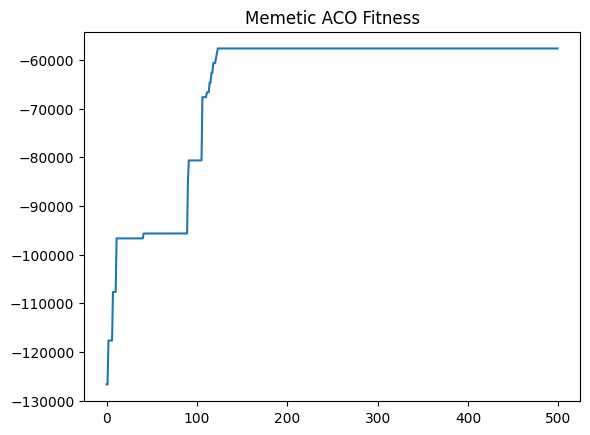

In [ ]:
import random
import time
import sys
import math
import matplotlib.pyplot as plt
import numpy as np

class ANT_COL_memetic:
    def __init__(self, input_file=None):
        self.input_file = input_file

    def read_input(self, file=None):
        if file is None:
            file = self.input_file
        if file:
            try:
                with open(file, 'r') as f:
                    lines = f.read().split()
            except FileNotFoundError:
                print(f"Error: File '{file}' not found.")
                sys.exit(1)
        else:
            lines = sys.stdin.read().split()

        iterator = iter(lines)
        try:
            N = int(next(iterator))
            K = int(next(iterator))
            quantity = []
            cost = []
            for _ in range(N):
                quantity.append(int(next(iterator)))
                cost.append(int(next(iterator)))
            lower_bound = []
            upper_bound = []
            for _ in range(K):
                lower_bound.append(int(next(iterator)))
                upper_bound.append(int(next(iterator)))

            self.orders_num = N
            self.vehicles_num = K
            self.quantity = quantity
            self.cost = cost
            self.lower_bound = lower_bound
            self.upper_bound = upper_bound

            self.ratio = []
            for i in range(N):
                denom = quantity[i] if quantity[i] > 0 else 0.1
                self.ratio.append(cost[i] / denom)
        except StopIteration:
            pass
    def get_max_possible_score(self):
        return sum(self.cost)

    def check_validation(self, load, v_idx):
        if load == 0: return True
        return self.lower_bound[v_idx] <= load <= self.upper_bound[v_idx]

    def calculate_fitness(self, individual):
        """
        Strict fitness calculation with penalties for invalid loads.
        """
        cost = 0
        veh_load = [0] * self.vehicles_num
        penalty = 1000
        punish_score = 0

        for order_idx, vehicle_idx in enumerate(individual):
            if vehicle_idx != -1:
                veh_load[vehicle_idx] += self.quantity[order_idx]
                cost += self.cost[order_idx]

        for vehicle_idx, load in enumerate(veh_load):
            if not self.check_validation(load, vehicle_idx):
                if load > self.upper_bound[vehicle_idx]:
                    punish_score += (load - self.upper_bound[vehicle_idx]) * penalty
                elif load > 0 and load < self.lower_bound[vehicle_idx]:
                    punish_score += (self.lower_bound[vehicle_idx] - load) * penalty

        return cost - punish_score

    def repair_solution(self, individual):
        load = [0] * self.vehicles_num
        assignments = individual[:]
        curr_cost = 0

        # 1. Greedy Load Check
        for order_idx, vehicle_idx in enumerate(individual):
            if vehicle_idx != -1:
                if load[vehicle_idx] + self.quantity[order_idx] <= self.upper_bound[vehicle_idx]:
                    load[vehicle_idx] += self.quantity[order_idx]
                    curr_cost += self.cost[order_idx]
                else:
                    assignments[order_idx] = -1

        # 2. Lower Bound Check
        for v_idx in range(self.vehicles_num):
            if load[v_idx] > 0 and load[v_idx] < self.lower_bound[v_idx]:
                for order_idx, veh_idx in enumerate(assignments):
                    if veh_idx == v_idx:
                        assignments[order_idx] = -1
                        curr_cost -= self.cost[order_idx]
                load[v_idx] = 0
        return assignments, curr_cost


    def ls_add_unassigned(self, assignments, load):
        """Try to add an unassigned item. Only checks Upper Bound."""
        unassigned_ord = [i for i, v in enumerate(assignments) if v == -1]
        random.shuffle(unassigned_ord) # Shuffle to try different items

        for add_ord in unassigned_ord:
            # Try random vehicles
            vehicle_order = list(range(self.vehicles_num))
            random.shuffle(vehicle_order)

            for v_idx in vehicle_order:
                if load[v_idx] + self.quantity[add_ord] <= self.upper_bound[v_idx]:
                    assignments[add_ord] = v_idx
                    load[v_idx] += self.quantity[add_ord]
                    return True # Change made
        return False

    def ls_move(self, assignments, load):
        """Relocate item from one vehicle to another."""
        assigned_ord = [i for i, v in enumerate(assignments) if v != -1]
        if not assigned_ord: return False

        # Try a few random moves
        for _ in range(20):
            remove_ord = random.choice(assigned_ord)
            remove_v = assignments[remove_ord]
            new_v = random.randint(0, self.vehicles_num - 1)

            if new_v != remove_v:
                # Check if fits in new (Only Upper Bound)
                if load[new_v] + self.quantity[remove_ord] <= self.upper_bound[new_v]:
                    assignments[remove_ord] = new_v
                    load[new_v] += self.quantity[remove_ord]
                    load[remove_v] -= self.quantity[remove_ord]
                    return True
        return False

    def ls_swap(self, assignments, load):
        """Swap items between two vehicles."""
        assigned_ord = [i for i, v in enumerate(assignments) if v != -1]
        if len(assigned_ord) < 2: return False

        for _ in range(20):
            ord1 = random.choice(assigned_ord)
            ord2 = random.choice(assigned_ord)
            v1 = assignments[ord1]
            v2 = assignments[ord2]

            if v1 == v2: continue

            q1 = self.quantity[ord1]
            q2 = self.quantity[ord2]

            new_load_v1 = load[v1] - q1 + q2
            new_load_v2 = load[v2] - q2 + q1 # Fix: v2 loses q2, gains q1

            if new_load_v1 <= self.upper_bound[v1] and new_load_v2 <= self.upper_bound[v2]:
                assignments[ord1] = v2
                assignments[ord2] = v1
                load[v1] = new_load_v1
                load[v2] = new_load_v2
                return True
        return False

    def apply_hill_climbing(self, individual, iterations=200):
        """
        Runs the improved stochastic hill climbing on a solution.
        """
        current_sol = individual[:]

        # Calculate load once
        current_load = [0] * self.vehicles_num
        for i, v in enumerate(current_sol):
            if v != -1: current_load[v] += self.quantity[i]

        for _ in range(iterations):
            # Always try to fill empty space first (Gradient Ascent)
            if self.ls_add_unassigned(current_sol, current_load):
                continue

            # If stuck, wiggle around (Random Walk)
            if random.random() < 0.5:
                self.ls_move(current_sol, current_load)
            else:
                self.ls_swap(current_sol, current_load)

        return current_sol

    def initialize_pheromones(self):
        self.pheromones = [[1.0 for _ in range(self.vehicles_num+1)] for _ in range(self.orders_num)]

    def select_vehicle_roulette(self, order_idx, cur_load, alpha, beta):
        vehicle_options = []
        probability = []

        for v_idx in range(self.vehicles_num):
            if cur_load[v_idx] + self.quantity[order_idx] <= self.upper_bound[v_idx]:
                vehicle_options.append(v_idx)
                heu = self.ratio[order_idx]
                pher = self.pheromones[order_idx][v_idx]
                score = (pher**alpha)*(heu**beta) # Corrected Math
                probability.append(score)

        pher_unassign = self.pheromones[order_idx][self.vehicles_num]
        heu_unassign = 0.01
        score_unassign = (pher_unassign**alpha)*(heu_unassign**beta)

        probability.append(score_unassign)
        vehicle_options.append(-1)

        total_prob = sum(probability)
        if total_prob == 0: return -1

        random_pick = random.uniform(0, total_prob)
        current_prob = 0
        for i, score in enumerate(probability):
            current_prob += score
            if random_pick <= current_prob:
               return vehicle_options[i]
        return vehicle_options[-1]

    def solve(self, generations=500, n_ants=50, alpha=2.0, beta=2.5, evaporation=0.1, Q=50, num_iters = 100):
        self.read_input()
        self.initialize_pheromones()
        time_start = time.time()
        max_score = self.get_max_possible_score()
        best_fitness = -float('inf')
        best_individual = None
        fit_his = []

        print(f"--- Starting Memetic ACO (Ants + Hill Climbing) ---")

        for gen in range(generations):
            gen_his = []

            # 1. Ant Construction Phase
            for _ in range(n_ants):
                ant_sol = [-1] * self.orders_num
                cur_load = [0] * self.vehicles_num
                for order_idx in range(self.orders_num):
                    sel_v = self.select_vehicle_roulette(order_idx, cur_load, alpha, beta)
                    ant_sol[order_idx] = sel_v
                    if sel_v != -1:
                        cur_load[sel_v] += self.quantity[order_idx]

                # Raw fitness
                fit = self.calculate_fitness(ant_sol)
                gen_his.append((ant_sol, fit))

            # 2. Select Best Ant of Generation
            gen_his.sort(key=lambda x: x[1], reverse=True)
            gen_best_sol = gen_his[0][0][:]

            # 3. Apply Hill Climbing (Improvement Phase)
            # Only apply to the elite ant to save time
            refined_sol = self.apply_hill_climbing(gen_best_sol, iterations=num_iters)
            refined_fit = self.calculate_fitness(refined_sol)

            # If refinement worked, use it. Otherwise keep raw ant solution.
            if refined_fit > gen_his[0][1]:
                final_gen_sol = refined_sol
                final_gen_fit = refined_fit
            else:
                final_gen_sol = gen_best_sol
                final_gen_fit = gen_his[0][1]

            # 4. Update Global Best
            if final_gen_fit > best_fitness:
                best_fitness = final_gen_fit
                best_individual = final_gen_sol[:]

            fit_his.append(best_fitness)

            # 5. Update Pheromones (Using the possibly refined Global Best)
            for i in range(self.orders_num):
                for v in range(self.vehicles_num+1):
                    self.pheromones[i][v] *= (1-evaporation)

            # Deposit logic (Standardized)
            deposit_base = Q * (max(0, best_fitness) / 10000.0) / self.orders_num
            if deposit_base <= 0: deposit_base = 0.001

            for i, v in enumerate(best_individual):
                idx = v if v != -1 else self.vehicles_num
                self.pheromones[i][idx] += deposit_base

            if gen % 20 == 0:
                print(f"Gen {gen}: Best Fitness = {best_fitness}")

        time_end = time.time() - time_start

        # Final cleanup
        if best_individual is None: best_individual = [-1]*self.orders_num
        final_assign, final_cost = self.repair_solution(best_individual)

        return final_assign, final_cost, time_end, fit_his, max_score

def main():
    # Usage
    solver = ANT_COL_memetic('test10.txt')
    best_assign, obj_val, duration, history, max_score = solver.solve()

    best_served = [(i+1, v+1) for i,v in enumerate(best_assign) if v!=-1]
    print(len(best_served))
    for i,v in best_served:
        print(f"{i} {v}")
    print(f"Objective: {obj_val}, Time: {duration:.2f}s")

    if history:
        plt.plot(history)
        plt.title("Memetic ACO Fitness")
        plt.show()

if __name__ == "__main__":
    main()

--- Starting (mu=15, lambda=250)-ES ---
255
3 29
4 93
6 96
15 31
17 93
26 78
28 98
30 56
38 41
57 54
62 29
66 66
74 39
76 92
77 71
78 96
79 8
80 51
83 39
85 43
86 13
93 75
94 35
100 27
101 24
109 23
110 96
113 24
115 89
121 48
123 31
128 47
129 23
133 23
136 73
137 17
140 8
143 13
144 29
154 62
155 14
156 98
157 77
160 71
167 35
176 80
180 77
192 35
200 19
201 56
209 29
213 87
214 35
215 62
216 29
217 62
221 24
222 43
235 39
250 62
253 89
255 53
256 39
261 73
267 4
269 62
274 59
282 13
286 93
289 89
302 4
304 67
305 51
306 23
309 54
310 75
311 75
315 66
316 75
319 27
323 79
326 71
330 25
351 62
361 75
373 37
375 66
382 77
383 8
387 54
388 77
390 23
396 14
400 39
403 70
405 53
406 64
414 77
416 23
422 87
424 59
428 14
429 62
431 35
432 35
441 4
445 37
450 87
454 54
456 24
461 54
465 27
471 62
474 56
478 27
482 67
485 39
486 34
494 41
495 8
508 23
514 89
515 98
516 43
518 43
522 98
524 35
527 89
529 66
535 77
536 41
537 31
550 70
559 62
561 27
569 47
573 25
575 14
586 34
587 98
588 35
59

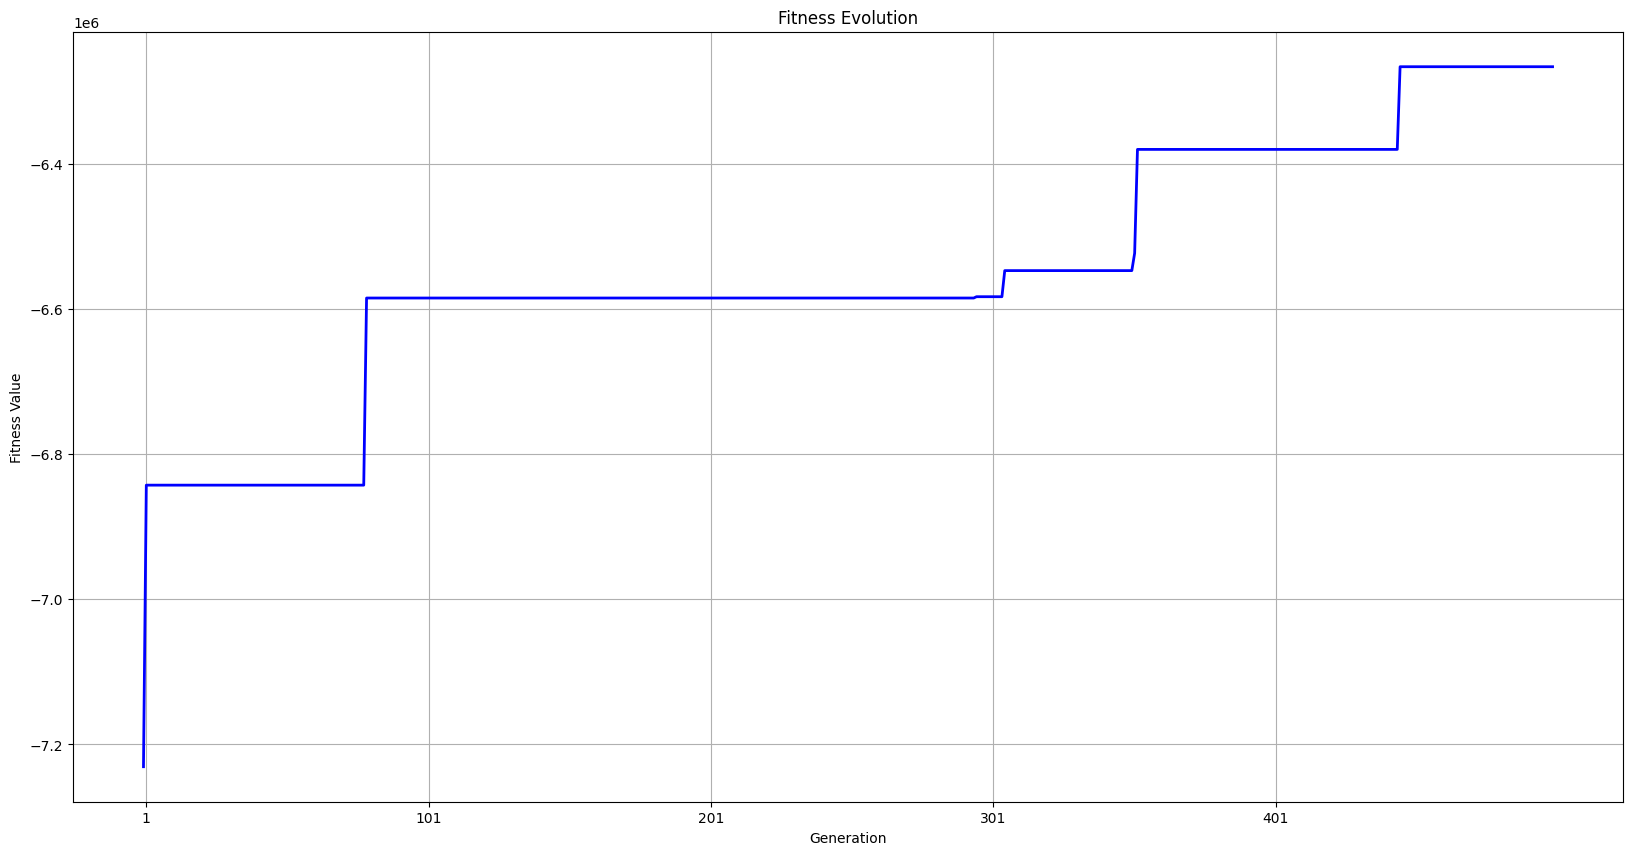

In [ ]:
#Simple Gaussian
class SIMPLE_GAUSSIAN_ES:
    def __init__(self, input_file=None):
        self.input_file = input_file
    '''def read_input(self):
        N, K = map(int, input().split())
        quantity = []
        cost = []
        for _ in range(N):
            q, c = map(int, input().split())
            quantity.append(q)
            cost.append(c)
        lower_bound = []
        upper_bound = []
        for _ in range(K):
            l, u = map(int, input().split())
            lower_bound.append(l)
            upper_bound.append(u)
        self.orders_num = N
        self.vehicles_num = K
        self.quantity = quantity
        self.cost = cost
        self.lower_bound = lower_bound
        self.upper_bound = upper_bound'''
    def read_input(self, file = None):
        if file is None:
            file = self.input_file
        with open(file, 'r') as f:
            N, K = map(int, f.readline().split())
            quantity = []
            cost = []
            for _ in range(N):
                q, c = map(int, f.readline().split())
                quantity.append(q)
                cost.append(c)
            lower_bound = []
            upper_bound = []
            for _ in range(K):
                l, u = map(int, f.readline().split())
                lower_bound.append(l)
                upper_bound.append(u)
        self.orders_num = N
        self.vehicles_num = K
        self.quantity = quantity
        self.cost = cost
        self.lower_bound = lower_bound
        self.upper_bound = upper_bound

    def get_max_possible_score(self):
        return sum(self.cost)

    def check_validation(self, load, v_idx):
        if load == 0:
            return True
        return self.lower_bound[v_idx] <= load <= self.upper_bound[v_idx]

    def calculate_fitness(self, individual):
        cost=0
        veh_load = [0] * self.vehicles_num
        penalty = 0
        for order_idx, vehicle_idx in enumerate(individual):
            if vehicle_idx != -1:
                veh_load[vehicle_idx] += self.quantity[order_idx]
                cost += self.cost[order_idx]
        for vehicle_idx, load in enumerate(veh_load):
            if self.check_validation(load,vehicle_idx):
                continue
            else:
                if load > self.upper_bound[vehicle_idx]:
                    penalty += (load-self.upper_bound[vehicle_idx])*1000
                elif load >0 and load < self.lower_bound[vehicle_idx]:
                    penalty += (self.lower_bound[vehicle_idx]-load)*1000

        return cost - penalty

    def repair_solution(self, individual):
        load = [0] * self.vehicles_num
        assignments = individual[:]
        curr_cost = 0
        lower_bound_violated = []
        upper_bound_violated = []
        unassign_orders = []
        #Adaptive repair
        for order_idx, vehicle_idx in enumerate(individual):
            if vehicle_idx != -1:
                load[vehicle_idx] += self.quantity[order_idx]
                curr_cost += self.cost[order_idx]
            else:
                unassign_orders.append(order_idx)
        for v_id in range(self.vehicles_num):
            if load[v_id]< self.lower_bound[v_id]:
                lower_bound_violated.append(v_id)
            elif load[v_id] > self.upper_bound[v_id]:
                upper_bound_violated.append(v_id)
        for v_id in upper_bound_violated:
            while load[v_id] > self.upper_bound[v_id]:
                for order_idx, veh_idx in enumerate(individual):
                    if veh_idx == v_id and random.random()<0.5:
                        assignments[order_idx] = -1
                        curr_cost -= self.cost[order_idx]
                        load[v_id] -= self.quantity[order_idx]
                        unassign_orders.append(order_idx)
        for v_id in lower_bound_violated:
            #try_time = 0
            #while load[v_id] < self.lower_bound[v_id] and try_time < 10:
                #try_time += 1
            for order_idx, veh_idx in enumerate(individual):
                if veh_idx == v_id:
                    assignments[order_idx] = -1
                    curr_cost -= self.cost[order_idx]
                    load[v_id] -= self.quantity[order_idx]

        return assignments, curr_cost

    def greedy(self, sorted_orders: str ="cost", sorted_vehicles: str = "lower_bound"):
        load = [0] * self.vehicles_num
        assignments = [-1] * self.orders_num
        orders_rate = []
        vehicle_rate = []
        curr_cost = 0
        if sorted_orders == "cost":
            for idx, cost in enumerate(self.cost):
                orders_rate.append((idx, cost))
        elif sorted_orders == "weight":
            for idx, weight in enumerate(self.quantity):
                orders_rate.append((idx, weight))
        elif sorted_orders == "ratio":
            for idx, (weight, cost) in enumerate(zip(self.quantity, self.cost)):
                orders_rate.append((idx, cost / weight))
        orders_rate.sort(key=lambda x: x[1], reverse=True)
        if sorted_vehicles == "lower_bound":
            for idx, lower in enumerate(self.lower_bound):
                vehicle_rate.append((idx, -lower))
        elif sorted_vehicles == "upper_bound":
            for idx, upper in enumerate(self.upper_bound):
                vehicle_rate.append((idx, -upper))
        elif sorted_vehicles == "range":
            for idx, (lower, upper) in enumerate(zip(self.lower_bound, self.upper_bound)):
                vehicle_rate.append((idx, upper - lower))
        vehicle_rate.sort(key=lambda x: x[1])

        for ord_idx, _ in orders_rate:
            for veh_idx, _ in vehicle_rate:
                if load[veh_idx] + self.quantity[ord_idx] <= self.upper_bound[veh_idx]:
                    assignments[ord_idx] = veh_idx
                    load[veh_idx] += self.quantity[ord_idx]
                    curr_cost += self.cost[ord_idx]
                    break
        for v_idx in range(self.vehicles_num):
            if load[v_idx] > 0 and load[v_idx] < self.lower_bound[v_idx]:
                for ord_idx, veh_idx in enumerate(assignments):
                    if veh_idx == v_idx:
                        assignments[ord_idx] = -1
                        curr_cost -= self.cost[ord_idx]
                load[v_idx] = 0
        return assignments, curr_cost, load
    def decode(self, continuous_vector):
        discrete_individual = []
        for val in continuous_vector:
            v = int(round(val))
            if -1 <= v <= self.vehicles_num - 1:
                discrete_individual.append(v)
            else:
                discrete_individual.append(-1) # Default to unassigned if outside range
        return discrete_individual
        '''
    def decode(self, continuous_vector):
        """
        Converts the continuous ES vector back to discrete vehicle assignments.
        Logic: Round to nearest int, then clamp to valid range [-1, vehicles-1].
        """
        discrete_individual = []
        for val in continuous_vector:
            # Round to nearest integer
            v = int(round(val))
            # Clamp to valid range: -1 (unassigned) to (K-1)
            v = max(-1, min(self.vehicles_num - 1, v))
            discrete_individual.append(v)
        return discrete_individual'''

    def solve(self, generation=500, lambda_off_spring=250, muy_parent =15, sigma=1.5):
        self.read_input()
        time_start = time.time()
        max_score = self.get_max_possible_score()
        #mean_vector = [random.uniform(-1, self.vehicles_num - 1) for _ in range(self.orders_num)]
        mean_vector = self.greedy("cost", "lower_bound")[0]
        best_individual = None
        best_fitness = -float('inf')

        fit_his = []
        #omega to store mean muy and standard deviant
        omega = []
        print(f"--- Starting (mu={muy_parent}, lambda={lambda_off_spring})-ES ---")
        for gen in range(generation):
            offspring_population = []
            #generate lambda offspring
            for _ in range(lambda_off_spring):
                child_vector = []
                for val in mean_vector:
                    #add gaussian noise to the mean
                    noise = random.gauss(0, sigma)
                    child_vector.append(val + noise)

                decode_child = self.decode(child_vector)
                fitness = self.calculate_fitness(decode_child)
                offspring_population.append((child_vector, fitness, decode_child))
            offspring_population.sort(key=lambda x: x[1], reverse=True)
            elites = offspring_population[:muy_parent]
            new_mean = [0.0] * self.orders_num
            for idx in range(self.orders_num):
                sum_val = sum(elite[0][idx] for elite in elites)
                new_mean[idx] = sum_val / muy_parent # Corrected: assign to new_mean[idx]
            mean_vector = new_mean
            if elites[0][1] > best_fitness:
                best_fitness = elites[0][1]
                best_individual = elites[0][2][:]
            fit_his.append(best_fitness)
            if gen%50 ==0:
                sigma *=0.98
                #print(f'Gen {gen} best fitness:{best_fitness}')
        time_duration = time.time() - time_start
        # Ensure best_individual is set, even if no improvement was made across generations
        if best_individual is None and offspring_population:
            best_individual = offspring_population[0][2][:]
        elif best_individual is None:
            # Fallback if no individuals were generated (e.g., generation=0)
            best_individual = self.decode(mean_vector) # Decode final mean as a last resort

        final_assignment, final_cost = self.repair_solution(best_individual)

        return final_assignment, final_cost, time_duration, fit_his, max_score

def main():
    solver = SIMPLE_GAUSSIAN_ES('test10.txt')
    best_assignment, objective_value, time_taken, fit_his, max_score = solver.solve() # Corrected: capture fit_his
    best_served_orders = [(i + 1, v + 1) for i, v in enumerate(best_assignment) if v != -1]
    print(len(best_served_orders))
    for order_idx, vehicle_idx in best_served_orders:
        print(f"{order_idx} {vehicle_idx}")
    print(f"Objective Value: {objective_value}, Time taken: {time_taken:.2f} seconds")
    print(f"Fitness History: {fit_his}")
    plt.figure(figsize=(20,10))
    plt.plot(fit_his, color='blue', linewidth=2)
    plt.title("Fitness Evolution")
    plt.xlabel("Generation")
    plt.ylabel("Fitness Value")
    plt.xticks(np.arange(1, len(fit_his)+1, 100))
    #ymin = min(fit_his) * 0.95
    #ymax = max(fit_his) * 1.05
    #plt.ylim(ymin,ymax)
    plt.grid(True)
    plt.show()
if __name__ == "__main__":
    main()

In [ ]:
import numpy as np
import random
import time
import pickle
import os


class DE():
    def __init__(self, dataset_path=None):
        """Constructor"""
        if dataset_path:
            self.dataset_path = dataset_path
            self.N, self.K, self.weights, self.values, self.truck_mins, self.truck_maxs = self.read_input(dataset_path)
            self.max_score = np.sum(self.values)
        else:
            self.dataset_path = None

    def read_input(self, filename):
        with open(filename, 'r') as f:
            lines = f.readlines()
        N, K = map(int, lines[0].split())

        weights = np.array([int(lines[i+1].split()[0]) for i in range(N)])
        values = np.array([int(lines[i+1].split()[1]) for i in range(N)])
        truck_mins = np.array([int(lines[N+1+k].split()[0]) for k in range(K)])
        truck_maxs = np.array([int(lines[N+1+k].split()[1]) for k in range(K)])

        return N, K, weights, values, truck_mins, truck_maxs

    def get_max_possible_score(self):
        return np.sum(self.values)

    def fitness(self, assign, weights, values, truck_mins, truck_maxs, alpha=20):
        assign = np.array(assign)
        K = len(truck_mins)

        valid_mask = assign >= 0
        truck_w = np.zeros(K)
        truck_v = np.zeros(K)

        if np.any(valid_mask):
            truck_indices = assign[valid_mask]
            truck_w = np.bincount(truck_indices, weights=weights[valid_mask], minlength=K)
            truck_v = np.bincount(truck_indices, weights=values[valid_mask], minlength=K)

        penalty = 0
        for k in range(K):
            if truck_w[k] > 0:
                if truck_w[k] < truck_mins[k]:
                    penalty += (truck_mins[k] - truck_w[k]) * alpha
                elif truck_w[k] > truck_maxs[k]:
                    penalty += (truck_w[k] - truck_maxs[k]) * alpha

        return truck_v.sum() - penalty

    def check_violations(self, assign, weights, values, truck_mins, truck_maxs):
        K = len(truck_mins)
        assign = np.array(assign)
        valid_mask = assign >= 0

        truck_w = np.zeros(K)
        truck_v = np.zeros(K)

        if np.any(valid_mask):
            truck_indices = assign[valid_mask]
            truck_w = np.bincount(truck_indices, weights=weights[valid_mask], minlength=K)
            truck_v = np.bincount(truck_indices, weights=values[valid_mask], minlength=K)

        violation_min = np.sum(truck_w < truck_mins)
        violation_max = np.sum(truck_w > truck_maxs)
        total_value = truck_v.sum()

        return violation_min + violation_max, total_value

    def greedy_init(self, N, K, weights, values, truck_mins, truck_maxs):
        assign = np.zeros(N, dtype=int)
        truck_w = np.zeros(K)
        ratios = values / (weights + 1e-6)
        sorted_idx = np.argsort(-ratios)

        for idx in sorted_idx:
            best_truck = 0
            best_score = -np.inf
            for k in range(K):
                new_w = truck_w[k] + weights[idx]
                if new_w <= truck_maxs[k]:
                    score = values[idx] - abs(new_w - truck_maxs[k]) * 0.01
                    if score > best_score:
                        best_score = score
                        best_truck = k
            assign[idx] = best_truck
            truck_w[best_truck] += weights[idx]

        return assign

    def mutate_discrete(self, a, b, c, K, F=0.8):
        v = a.copy()
        diff_pos = np.where(b != c)[0]

        if len(diff_pos) > 0:
            n_change = max(1, int(F * len(diff_pos)))
            change_pos = np.random.choice(diff_pos, n_change, replace=False)

            for i in change_pos:
                r = random.random()
                if r < 0.45:
                    v[i] = b[i]
                elif r < 0.9:
                    v[i] = c[i]
                else:
                    v[i] = random.randint(0, K-1)

        return v

    def crossover_discrete(self, v, x, Cr=0.9):
        u = x.copy()
        N = len(x)
        j_rand = random.randint(0, N-1)

        for i in range(N):
            if random.random() < Cr or i == j_rand:
                u[i] = v[i]

        return u

    def local_search(self, ind, weights, values, truck_mins, truck_maxs, alpha):
        best = ind.copy()
        best_fit = self.fitness(best, weights, values, truck_mins, truck_maxs, alpha)
        K = len(truck_mins)
        N = len(ind)

        for _ in range(10):
            i = random.randint(0, N-1)
            old_truck = best[i]
            new_truck = random.randint(0, K-1)

            if new_truck != old_truck:
                best[i] = new_truck
                new_fit = self.fitness(best, weights, values, truck_mins, truck_maxs, alpha)
                if new_fit > best_fit:
                    best_fit = new_fit
                else:
                    best[i] = old_truck

        return best

    def hybrid_de(self, filename, pop_size=100, max_gen=500, F=0.8, Cr=0.9, verbose=True):
        """Original hybrid_de với full output"""
        N, K, weights, values, truck_mins, truck_maxs = self.read_input(filename)

        # Initialize population
        pop = []
        n_greedy = int(pop_size * 0.2)
        for _ in range(n_greedy):
            pop.append(self.greedy_init(N, K, weights, values, truck_mins, truck_maxs))
        for _ in range(pop_size - n_greedy):
            pop.append(np.random.randint(0, K, size=N))

        best_ind = pop[0].copy()
        best_fit = -np.inf
        no_improve = 0
        fitness_history = []

        for gen in range(max_gen):
            alpha = 20 + 80 * (gen / 300)

            if no_improve > 20:
                F_use = random.uniform(0.5, 1.0)
                Cr_use = random.uniform(0.8, 1.0)
            else:
                F_use = F
                Cr_use = Cr

            improved = False

            for i in range(pop_size):
                candidates = [j for j in range(pop_size) if j != i]
                ia, ib, ic = random.sample(candidates, 3)

                v = self.mutate_discrete(pop[ia], pop[ib], pop[ic], K, F_use)
                u = self.crossover_discrete(v, pop[i], Cr_use)

                if random.random() < 0.1:
                    u = self.local_search(u, weights, values, truck_mins, truck_maxs, alpha)

                fit_u = self.fitness(u, weights, values, truck_mins, truck_maxs, alpha)
                fit_i = self.fitness(pop[i], weights, values, truck_mins, truck_maxs, alpha)

                if fit_u >= fit_i:
                    pop[i] = u
                    if fit_u > best_fit:
                        best_fit = fit_u
                        best_ind = u.copy()
                        improved = True

            if improved:
                no_improve = 0
            else:
                no_improve += 1

            fitness_history.append(best_fit)

            if no_improve > 40:
                if verbose:
                    print(f"  Gen {gen}: Restart 30%")
                fits = [self.fitness(ind, weights, values, truck_mins, truck_maxs, alpha) for ind in pop]
                worst_idx = np.argsort(fits)[:int(pop_size*0.3)]
                for idx in worst_idx:
                    if random.random() < 0.5:
                        pop[idx] = self.greedy_init(N, K, weights, values, truck_mins, truck_maxs)
                    else:
                        pop[idx] = np.random.randint(0, K, size=N)
                no_improve = 0

            if verbose and (gen % 50 == 0 or gen == max_gen - 1):
                print(f"Gen {gen:3d}: fitness = {best_fit:8.1f}  (alpha={alpha:.1f})")

        return best_ind, fitness_history

    def repair(self, assign, weights, values, truck_mins, truck_maxs):
        assign = np.array(assign)
        N = len(assign)
        K = len(truck_mins)

        valid_mask = assign >= 0
        truck_w = np.zeros(K)
        if np.any(valid_mask):
            idx = assign[valid_mask]
            truck_w = np.bincount(idx, weights=weights[valid_mask], minlength=K)

        repaired = assign.copy()

        for k in range(K):
            load = truck_w[k]
            if load == 0:
                continue

            if load < truck_mins[k]:
                order_idxs = np.where(repaired == k)[0]
                repaired[order_idxs] = -1
                truck_w[k] = 0
                continue

            if load > truck_maxs[k]:
                overweight = load - truck_maxs[k]
                order_idxs = np.where(repaired == k)[0]
                ratios = values[order_idxs] / (weights[order_idxs] + 1e-6)
                sorted_order = order_idxs[np.argsort(ratios)]

                for i in sorted_order:
                    repaired[i] = -1
                    overweight -= weights[i]
                    if overweight <= 0:
                        break

        return repaired

    def write_output(self, solution, weights, values, truck_mins, truck_maxs, filename="output.txt"):
        """Write output như bản gốc"""
        violations, total_value = self.check_violations(solution, weights, values, truck_mins, truck_maxs)
        final_fitness = self.fitness(solution, weights, values, truck_mins, truck_maxs, alpha=50)

        print(f"\n{'='*60}")
        print(f"SOLUTION SUMMARY")
        print(f"{'='*60}")
        print(f"Total value:     {total_value:.1f}")
        print(f"Final fitness:   {final_fitness:.1f}")
        print(f"\n Written to {filename}")
        print(f"{'='*60}")

    def plot_convergence(self, fitness_history, test_filename):
        """Plot convergence như bản gốc"""
        try:
            import matplotlib.pyplot as plt
            plt.figure(figsize=(10, 5))
            plt.plot(fitness_history, linewidth=2)
            plt.xlabel('Generation')
            plt.ylabel('Best Fitness')
            plt.title(f'DE Convergence for {test_filename}')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Error plotting: {e}")

    def run_optimization(self, test_filename, pop_size=50, max_gen=300, F=0.7, Cr=0.8):
        print("="*60)
        print(f"RUNNING DISCRETE DE FOR {test_filename}")
        print("="*60)

        solution, fitness_history = self.hybrid_de(
            filename=test_filename,
            pop_size=pop_size,
            max_gen=max_gen,
            F=F,
            Cr=Cr,
            verbose=True  # Full output
        )

        N, K, weights, values, truck_mins, truck_maxs = self.read_input(test_filename)
        output_filename = f"output_{test_filename}"
        solution = self.repair(solution, weights, values, truck_mins, truck_maxs)
        self.write_output(solution, weights, values, truck_mins, truck_maxs, filename=output_filename)

        # Plot
        self.plot_convergence(fitness_history, test_filename)

    def solve(self, pop_size=50, max_gen=300, F=0.7, Cr=0.8):
        """
        Hàm solve cho tuning

        Returns:
            best_assignment: Solution array
            objective_value: Final value achieved
            time_taken: Time in seconds
            fit_his: Fitness history
            max_score: Maximum possible score
        """
        start_time = time.time()

        solution, fitness_history = self.hybrid_de(
            filename=self.dataset_path,
            pop_size=pop_size,
            max_gen=max_gen,
            F=F,
            Cr=Cr,
            verbose=False  # Không print khi tune
        )

        # Repair solution
        solution = self.repair(solution, self.weights, self.values,
                             self.truck_mins, self.truck_maxs)

        # Calculate final objective value
        assign = np.array(solution)
        valid_mask = assign >= 0
        objective_value = 0

        if np.any(valid_mask):
            truck_indices = assign[valid_mask]
            truck_v = np.bincount(truck_indices,
                                weights=self.values[valid_mask],
                                minlength=self.K)
            objective_value = truck_v.sum()

        time_taken = time.time() - start_time

        return solution, objective_value, time_taken, fitness_history, self.max_score

RUNNING DISCRETE DE FOR test6.txt
Gen   0: fitness =  -1051.0  (alpha=10.0)
Gen  50: fitness =   1128.6  (alpha=12.0)
  Gen 52: Restart 30%
Gen 100: fitness =   1139.0  (alpha=14.0)
  Gen 129: Restart 30%
Gen 150: fitness =   1139.0  (alpha=16.0)
  Gen 170: Restart 30%
Gen 200: fitness =   1139.0  (alpha=15.0)
  Gen 211: Restart 30%
Gen 250: fitness =   1139.0  (alpha=21.7)
  Gen 252: Restart 30%
  Gen 293: Restart 30%
Gen 299: fitness =   1139.0  (alpha=28.2)

SOLUTION SUMMARY
Total value:     1139.0
Final fitness:   1139.0

 Written to output_test6.txt


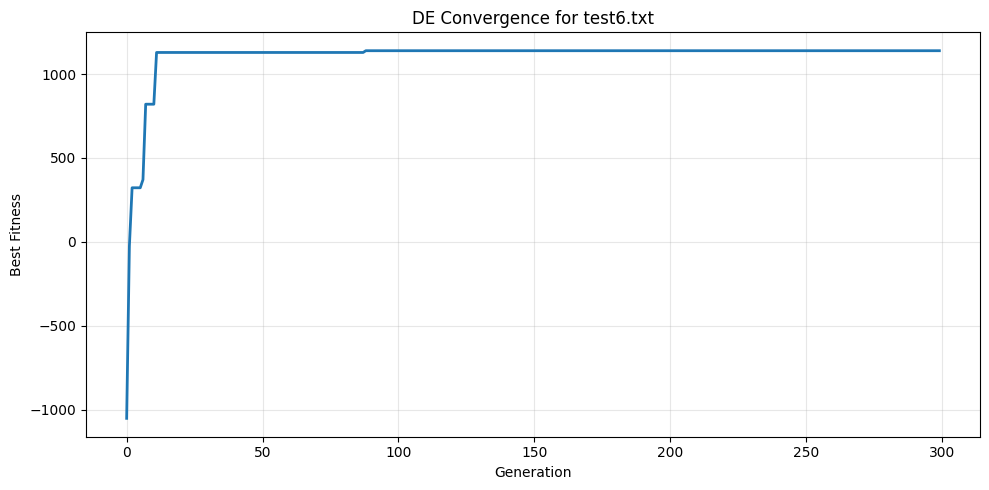

In [ ]:
run_optimization(test_filename='test6.txt', pop_size=50, max_gen=300, F=0.7, Cr=0.8)

RUNNING DISCRETE DE FOR test5.txt
Gen   0: fitness =  -5448.0  (alpha=10.0)
Gen  50: fitness =   1999.0  (alpha=12.0)
Gen 100: fitness =   2102.0  (alpha=14.0)
  Gen 118: Restart 30%
Gen 150: fitness =   2102.0  (alpha=16.0)
  Gen 159: Restart 30%
  Gen 200: Restart 30%
Gen 200: fitness =   2102.0  (alpha=15.0)
  Gen 241: Restart 30%
Gen 250: fitness =   2102.0  (alpha=21.7)
  Gen 282: Restart 30%
Gen 299: fitness =   2102.0  (alpha=28.2)

SOLUTION SUMMARY
Total value:     2102.0
Final fitness:   2102.0

 Written to output_test5.txt


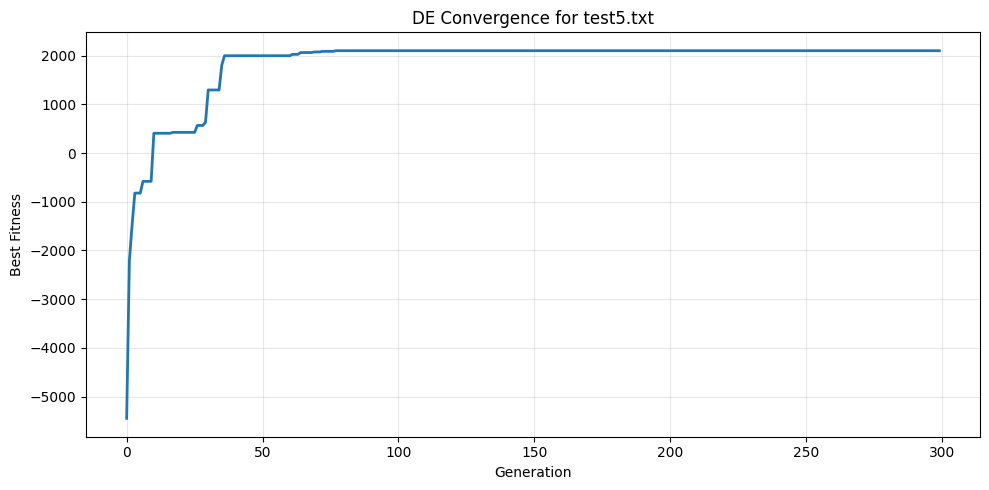

In [ ]:
run_optimization(test_filename='test5.txt', pop_size=50, max_gen=300, F=0.7, Cr=0.8)

RUNNING DISCRETE DE FOR test7.txt
Gen   0: fitness =  -6547.0  (alpha=10.0)
Gen  50: fitness =   2703.7  (alpha=12.0)
Gen 100: fitness =   2884.7  (alpha=14.0)
Gen 150: fitness =   3017.1  (alpha=16.0)
  Gen 188: Restart 30%
Gen 200: fitness =   3018.0  (alpha=15.0)
  Gen 241: Restart 30%
Gen 250: fitness =   3018.0  (alpha=21.7)
  Gen 282: Restart 30%
Gen 299: fitness =   3018.0  (alpha=28.2)

SOLUTION SUMMARY
Total value:     3032.0
Final fitness:   582.0

 Written to output_test7.txt


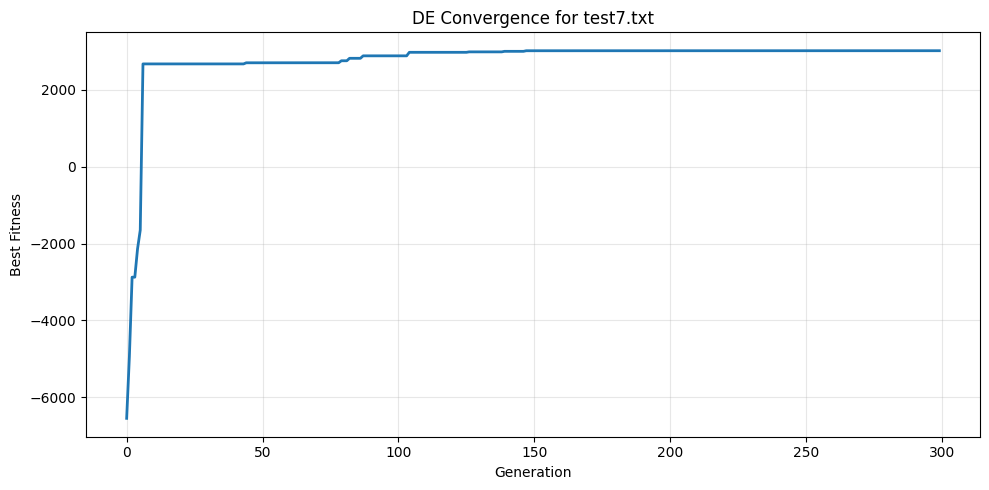

In [ ]:
run_optimization(test_filename='test7.txt', pop_size=50, max_gen=300, F=0.7, Cr=0.8)

In [ ]:
pip install optuna

In [ ]:
pip install optuna[visualization]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 7.4 MB/s eta 0:00:00


In [ ]:
import optuna
import numpy as np
import random

def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)

def tune_params(AlgorithmClass, params_selector, dataset_paths, n_seeds=5, n_trials=10):

    if isinstance(dataset_paths, str):
        dataset_paths = [dataset_paths]

    def objective(trial):
        params = params_selector(trial)

        # Danh sách chứa % hoàn thành của từng dataset
        # Ví dụ: [0.95, 0.80, 0.99] (tương ứng dataset 1, 2, 3)
        dataset_mean_ratios = []

        # 1. Lặp qua từng Dataset
        for dataset_path in dataset_paths:

            # Lưu tỷ lệ của từng seed trong dataset này
            current_dataset_ratios = []

            # 2. Chạy N Seeds cho dataset hiện tại
            for i in range(n_seeds):
                current_seed = 42 + i
                set_seed(current_seed)

                model = AlgorithmClass(dataset_path)

                # Chạy thuật toán
                best_assignment, objective_value, time_taken, fit_his, max_score = model.solve(**params)

                # Tính tỷ lệ đạt được (0.0 -> 1.0)
                ratio = objective_value / max_score
                current_dataset_ratios.append(ratio)

                # (Optional) Log chi tiết
                print(f"  [DS: {dataset_path} | Seed {current_seed}] Params: {params} Val: {objective_value:.2f}/{max_score} ({ratio:.2%})")

            # Tính trung bình tỷ lệ của dataset này qua 5 seeds và lưu lại
            avg_ratio_for_this_dataset = np.mean(current_dataset_ratios)
            dataset_mean_ratios.append(avg_ratio_for_this_dataset)

        # 3. Kết quả cuối cùng là trung bình cộng tỷ lệ của TẤT CẢ datasets
        final_avg_ratio = np.mean(dataset_mean_ratios)

        print(f"Trial {trial.number}: Global Avg Ratio = {final_avg_ratio*100:.2f}% | Params = {params}")

        return final_avg_ratio

    # Tắt log chi tiết
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    study = optuna.create_study(direction='maximize')

    # Kiểm tra n_trials
    if n_trials < 1:
        print("Lỗi: n_trials phải lớn hơn 0. Đang đặt lại n_trials=10")
        n_trials = 10

    print(f"Bắt đầu Tuning trên {len(dataset_paths)} datasets với {n_trials} trials...")
    study.optimize(objective, n_trials=n_trials)

    print("\n" + "="*40)
    print(f"--- KẾT QUẢ TỐT NHẤT CHO {AlgorithmClass.__name__} ---")
    print(f"Best Ratio : {study.best_value*100:.2f}% of Max Potential")
    print("Best Params:")
    for key, val in study.best_params.items():
        if isinstance(val, float):
            print(f"  - {key}: {val:.2f}")
        else:
            print(f"  - {key}: {val}")
    print("="*40 + "\n")

    return study.best_params

In [ ]:
def ga_params_selector(trial):
    return{
        'population_size': trial.suggest_int('population_size', 50, 200, step=50),
        'generations' : trial.suggest_categorical('generations',[300,400,500,1000,1500,2000]),
        'cross_over_rate' : trial.suggest_float('cross_over_rate',0.75,0.95, step=0.05),
        'mutation_rate' : trial.suggest_categorical('mutation_rate',[0.01,0.05,0.1,0.15,0.2,0.25,0.3,0.4]),
        'elitism_count' : trial.suggest_int('elitism_count',2,5)
    }


In [ ]:
def gp_params_selector(trial):
    return {
        'pop_size': trial.suggest_int('pop_size', 10, 40, step=10),
        'generations': trial.suggest_int('generations', 10, 40, step=10),
        'tournament_size': trial.suggest_int('tournament_size', 3, 5),
        'crossover_rate': trial.suggest_float('crossover_rate', 0.6, 0.9, step=0.1),
        'mutation_rate': trial.suggest_float('mutation_rate', 0.1, 0.3, step=0.1),
        'max_tree_depth': trial.suggest_int('max_tree_depth', 3, 5)
    }

datasets = ['test10.txt']

best_gp_params = tune_params(
    AlgorithmClass=GP_ALG,
    params_selector=gp_params_selector,
    dataset_paths=datasets,
    n_seeds=2,
    n_trials=10
)

Bắt đầu Tuning trên 1 datasets với 10 trials...
  [DS: test10.txt | Seed 43] Params: {'pop_size': 10, 'generations': 20, 'tournament_size': 3, 'crossover_rate': 0.8, 'mutation_rate': 0.3, 'max_tree_depth': 4} Val: 9737.00/10380 (93.81%)
  [DS: test10.txt | Seed 44] Params: {'pop_size': 10, 'generations': 20, 'tournament_size': 3, 'crossover_rate': 0.8, 'mutation_rate': 0.3, 'max_tree_depth': 4} Val: 9918.00/10380 (95.55%)
Trial 0: Global Avg Ratio = 94.68% | Params = {'pop_size': 10, 'generations': 20, 'tournament_size': 3, 'crossover_rate': 0.8, 'mutation_rate': 0.3, 'max_tree_depth': 4}
  [DS: test10.txt | Seed 43] Params: {'pop_size': 20, 'generations': 40, 'tournament_size': 4, 'crossover_rate': 0.7, 'mutation_rate': 0.1, 'max_tree_depth': 3} Val: 9737.00/10380 (93.81%)
  [DS: test10.txt | Seed 44] Params: {'pop_size': 20, 'generations': 40, 'tournament_size': 4, 'crossover_rate': 0.7, 'mutation_rate': 0.1, 'max_tree_depth': 3} Val: 9852.00/10380 (94.91%)
Trial 1: Global Avg Ratio 

In [ ]:
def ep_params_selector(trial):
    return{
        'population_size' : trial.suggest_int('population_size',100,500,step=50),
        'generations' : trial.suggest_categorical('generations',[300,400,500,700,1000,1500]),
        'mutation_rate' : 1,
        'elitism_count': trial.suggest_int('elitism_count',3,15)
    }

In [ ]:
def de_params_selector(trial):
    """Parameter selector for Optuna"""
    return {
        'pop_size': trial.suggest_int('pop_size', 50, 200, step=50),
        'max_gen': trial.suggest_int('max_gen', 200, 500, step=100),
        'F': trial.suggest_float('F', 0.5, 1.0, step=0.1),
        'Cr': trial.suggest_float('Cr', 0.7, 1.0, step=0.1)
    }

In [ ]:
best_de_params = tune_params(
    DE,
    de_params_selector,
    ['test8.txt','test4.txt','test3.txt','test10.txt'],
    n_seeds=5,
    n_trials=20
)

Bắt đầu Tuning trên 4 datasets với 20 trials...
  [DS: test8.txt | Seed 42] Params: {'pop_size': 100, 'max_gen': 400, 'F': 0.7, 'Cr': 0.8999999999999999} Val: 4408.00/5227 (84.33%)
  [DS: test8.txt | Seed 43] Params: {'pop_size': 100, 'max_gen': 400, 'F': 0.7, 'Cr': 0.8999999999999999} Val: 5123.00/5227 (98.01%)
  [DS: test8.txt | Seed 44] Params: {'pop_size': 100, 'max_gen': 400, 'F': 0.7, 'Cr': 0.8999999999999999} Val: 4640.00/5227 (88.77%)
  [DS: test8.txt | Seed 45] Params: {'pop_size': 100, 'max_gen': 400, 'F': 0.7, 'Cr': 0.8999999999999999} Val: 5224.00/5227 (99.94%)
  [DS: test8.txt | Seed 46] Params: {'pop_size': 100, 'max_gen': 400, 'F': 0.7, 'Cr': 0.8999999999999999} Val: 4714.00/5227 (90.19%)
  [DS: test4.txt | Seed 42] Params: {'pop_size': 100, 'max_gen': 400, 'F': 0.7, 'Cr': 0.8999999999999999} Val: 8119.00/8559 (94.86%)
  [DS: test4.txt | Seed 43] Params: {'pop_size': 100, 'max_gen': 400, 'F': 0.7, 'Cr': 0.8999999999999999} Val: 8553.00/8559 (99.93%)
  [DS: test4.txt | Se

In [ ]:
def aco_params_selector(trial):
    return{
        'generations' : trial.suggest_int('generations',200,500,step=50),
        'n_ants' : trial.suggest_int('n_ants',20,100,step=10),
        'alpha' : trial.suggest_float('alpha',1.5,4.0,step=0.5),
        'beta' : trial.suggest_float('beta',1.5,4.0,step=0.5),
        'evaporation' : trial.suggest_float('evaporation',0.05,0.5,step=0.05),
        'Q' : trial.suggest_int('Q',10,70,step=5),
        'num_iters' : trial.suggest_int('num_iters',50,500,step=50)
    }

In [ ]:
data_paths=['test8.txt','test4.txt','test3.txt','test10.txt']

In [ ]:
#Thứ tự data test 500, 800, 900, 1000
data_paths=['test8.txt','test4.txt','test3.txt','test10.txt']
best_ga_params = tune_params(GENENTIC_ALG, ga_params_selector, dataset_paths=data_paths)

Bắt đầu Tuning trên 4 datasets với 10 trials...
  [DS: test8.txt | Seed 42] Params: {'population_size': 100, 'generations': 1000, 'cross_over_rate': 0.95, 'mutation_rate': 0.25, 'elitism_count': 5} Val: 5100.00/5227 (97.57%)
  [DS: test8.txt | Seed 43] Params: {'population_size': 100, 'generations': 1000, 'cross_over_rate': 0.95, 'mutation_rate': 0.25, 'elitism_count': 5} Val: 4367.00/5227 (83.55%)
  [DS: test8.txt | Seed 44] Params: {'population_size': 100, 'generations': 1000, 'cross_over_rate': 0.95, 'mutation_rate': 0.25, 'elitism_count': 5} Val: 4925.00/5227 (94.22%)
  [DS: test8.txt | Seed 45] Params: {'population_size': 100, 'generations': 1000, 'cross_over_rate': 0.95, 'mutation_rate': 0.25, 'elitism_count': 5} Val: 3629.00/5227 (69.43%)
  [DS: test8.txt | Seed 46] Params: {'population_size': 100, 'generations': 1000, 'cross_over_rate': 0.95, 'mutation_rate': 0.25, 'elitism_count': 5} Val: 5100.00/5227 (97.57%)
  [DS: test4.txt | Seed 42] Params: {'population_size': 100, 'gener

In [ ]:
best_ep_params = tune_params(EVOLUTIONARY_PROGRAMMING, ep_params_selector, dataset_paths=data_paths)

Bắt đầu Tuning trên 4 datasets với 10 trials...
  [DS: test8.txt | Seed 42] Params: {'population_size': 150, 'generations': 500, 'mutation_rate': 1, 'elitism_count': 7} Val: 5100.00/5227 (97.57%)
  [DS: test8.txt | Seed 43] Params: {'population_size': 150, 'generations': 500, 'mutation_rate': 1, 'elitism_count': 7} Val: 4456.00/5227 (85.25%)
  [DS: test8.txt | Seed 44] Params: {'population_size': 150, 'generations': 500, 'mutation_rate': 1, 'elitism_count': 7} Val: 5213.00/5227 (99.73%)
  [DS: test8.txt | Seed 45] Params: {'population_size': 150, 'generations': 500, 'mutation_rate': 1, 'elitism_count': 7} Val: 5100.00/5227 (97.57%)
  [DS: test8.txt | Seed 46] Params: {'population_size': 150, 'generations': 500, 'mutation_rate': 1, 'elitism_count': 7} Val: 5227.00/5227 (100.00%)
  [DS: test4.txt | Seed 42] Params: {'population_size': 150, 'generations': 500, 'mutation_rate': 1, 'elitism_count': 7} Val: 8514.00/8559 (99.47%)
  [DS: test4.txt | Seed 43] Params: {'population_size': 150, 'g

In [ ]:
def ep_params_selector_2(trial):
    return{
        'population_size' : trial.suggest_int('population_size',100,500,step=50),
        'generations' : trial.suggest_int('generations',500,1500,step=100),
        'mutation_rate' : 1,
        'elitism_count': trial.suggest_int('elitism_count',3,15)
    }

In [ ]:
best_ep_params_2 = tune_params(EVOLUTIONARY_PROGRAMMING, ep_params_selector_2, dataset_paths=data_paths)

Bắt đầu Tuning trên 4 datasets với 10 trials...
  [DS: test8.txt | Seed 42] Params: {'population_size': 250, 'generations': 1000, 'mutation_rate': 1, 'elitism_count': 12} Val: 5227.00/5227 (100.00%)
  [DS: test8.txt | Seed 43] Params: {'population_size': 250, 'generations': 1000, 'mutation_rate': 1, 'elitism_count': 12} Val: 5227.00/5227 (100.00%)
  [DS: test8.txt | Seed 44] Params: {'population_size': 250, 'generations': 1000, 'mutation_rate': 1, 'elitism_count': 12} Val: 5213.00/5227 (99.73%)
  [DS: test8.txt | Seed 45] Params: {'population_size': 250, 'generations': 1000, 'mutation_rate': 1, 'elitism_count': 12} Val: 5227.00/5227 (100.00%)
  [DS: test8.txt | Seed 46] Params: {'population_size': 250, 'generations': 1000, 'mutation_rate': 1, 'elitism_count': 12} Val: 5227.00/5227 (100.00%)
  [DS: test4.txt | Seed 42] Params: {'population_size': 250, 'generations': 1000, 'mutation_rate': 1, 'elitism_count': 12} Val: 8494.00/8559 (99.24%)
  [DS: test4.txt | Seed 43] Params: {'population

In [ ]:
def cmaes_params_selector(trial):
    return{
        'generations' : trial.suggest_int('generations',200,500,step=50),
        'sigma': trial.suggest_float('sigma', 0.2, 1.5),
        'popsize_factor': trial.suggest_float('popsize_factor', 1.0, 4.0),
        'penalty_factor': trial.suggest_int('penalty_factor', 200, 2000, step=200)
    }

In [ ]:
data_paths = ['test8.txt', 'test4.txt', 'test3.txt', 'test10.txt']

best_cmaes_params = tune_params(EVOLUTIONARY_STRATEGY, cmaes_params_selector, dataset_paths=data_paths)